In [165]:
import pandas as pd
from sklearn.cluster import KMeans
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import unicodedata
import re
import gower

import kmedoids # Nueva librería para PAM
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.spatial.distance as ssd
import prince
import numpy as np


In [166]:
trainset = pd.read_csv("../trainset.csv")

In [167]:
trainset.head()

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,tamano_manguito_pa_4.0,tamano_manguito_pa_5.0,estado_elastografia_1,tipo_sonda_elasto_b'M',tipo_sonda_elasto_b'XL',raza_etnia_2.0,raza_etnia_3.0,raza_etnia_4.0,raza_etnia_6.0,raza_etnia_7.0
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [168]:
print(trainset.shape)

(1919, 69)


In [169]:
trainset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1919 entries, 0 to 1918
Data columns (total 69 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   edad_an                         1919 non-null   float64
 1   tamano_hogar                    1919 non-null   float64
 2   psu                             1919 non-null   float64
 3   ratio_pobreza                   1919 non-null   float64
 4   tiempo_seg_cond1                1919 non-null   float64
 5   tiempo_seg_cond2                1919 non-null   float64
 6   tiempo_seg_cond3                1919 non-null   float64
 7   tiempo_seg_cond4                1919 non-null   float64
 8   pulso                           1919 non-null   float64
 9   peso_kg                         1919 non-null   float64
 10  altura_cm                       1919 non-null   float64
 11  imc                             1919 non-null   float64
 12  largo_pierna_superior_cm        19

In [170]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas = [col for col in cols_categoricas if col in trainset.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas = [col for col in cols_numericas if col in trainset.columns]

trainset[var_numericas] = trainset[var_numericas].astype('float64')
trainset[var_categoricas] = trainset[var_categoricas].astype('object')

print(f"Número de columnas categóricas: {len(var_categoricas)}")
print(var_categoricas)

print(f"Número de columnas numéricas: {len(var_numericas)}")
print(var_numericas)

Número de columnas categóricas: 0
[]
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl', 'volumen_corpuscular_medio', 'conc_hemoglobina_media', 'ancho_distribucion_eritrocitos', 'plaquetas_totales', 'volumen_plaquetario_medio', 'trigliceridos_mmol_l', 'ldl_martin_mmol_l', 'hdl_mmol_l', 'plomo_sangre_umol_l', 'cadmio_sangre_nmol_l', 'mercurio_sangre_nmol_l', 'selenio_sangre_umol_l', 

Separamos solo las variables numericas, para k-means.

In [171]:
X_train = trainset.select_dtypes(include=['number'])
X_train.shape

(1919, 69)

## Clustering con K-MEANS

In [172]:
silhouette_scores = {}

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_train)
    score = silhouette_score(X_train, labels)
    silhouette_scores[k] = score
    print(f"Para K={k}, el Silhouette Score es: {score:.4f}")

Para K=2, el Silhouette Score es: 0.0890
Para K=3, el Silhouette Score es: 0.0512
Para K=4, el Silhouette Score es: 0.0467
Para K=5, el Silhouette Score es: 0.0333


In [173]:
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nEl K óptimo según el Silhouette Score es: K={best_k} (Score: {silhouette_scores[best_k]:.4f})")


El K óptimo según el Silhouette Score es: K=2 (Score: 0.0890)


## USANDO K-PROTOTYPES

In [174]:
var_categoricas = [
    'genero_1', 'periodo_examen_1', 'pais_nacimiento_1', 'toma_suplementos_1', 
    'toma_antiacidos_1', 'estado_examen_balance_1', 'elegibilidad_balance_1', 
    'convulsiones_1', 'caidas_1', 'fracturas_1', 'medicacion_osteoporosis_1', 
    'aprueba_cond4_1', 'tamano_manguito_pa_3.0', 'tamano_manguito_pa_4.0', 
    'tamano_manguito_pa_5.0', 'estado_elastografia_1', "tipo_sonda_elasto_b'M'", 
    "tipo_sonda_elasto_b'XL'", 'raza_etnia_2.0', 'raza_etnia_3.0', 
    'raza_etnia_4.0', 'raza_etnia_6.0', 'raza_etnia_7.0'
]

In [175]:
cat_indices = [trainset.columns.get_loc(col) for col in var_categoricas]
print(f"Índices de columnas categóricas: {cat_indices}")
print(f"Columnas categóricas: {len(cat_indices)}")

Índices de columnas categóricas: [46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]
Columnas categóricas: 23


In [176]:
matriz_datos = trainset.to_numpy()

In [177]:
print("Calculando la matriz de Distancia de Gower...")
matriz_distancias_gower = gower.gower_matrix(trainset)

Calculando la matriz de Distancia de Gower...


In [178]:
# 3. Evaluar K entre 2 y 5
resultados_silhouette = {}
mejor_k = -1
mejor_score = -1

print("\nEntrenando K-Prototypes y calculando Silhouette Scores:")
for k in range(2, 6):
    # Entrenar K-Prototypes
    kproto = KPrototypes(n_clusters=k, init='Cao', n_jobs=-1, random_state=42)
    etiquetas_clusters = kproto.fit_predict(matriz_datos, categorical=cat_indices)
    
    # Calcular Silhouette Score usando la matriz de Gower precalculada
    # metric='precomputed' le dice a sklearn que no intente calcular distancias euclidianas
    score = silhouette_score(matriz_distancias_gower, etiquetas_clusters, metric='precomputed')
    
    resultados_silhouette[k] = score
    print(f"Para K={k} -> Silhouette Score (Gower): {score:.4f}")
    
    # Guardar el mejor resultado
    if score > mejor_score:
        mejor_score = score
        mejor_k = k

# 4. Mostrar el veredicto final
print("-" * 40)
print(f"El conjunto óptimo es K = {mejor_k} con un Silhouette Score de {mejor_score:.4f}")


Entrenando K-Prototypes y calculando Silhouette Scores:


KeyboardInterrupt: 

Se han modificado los datasets para eliminar el proceso del OHE de cara a probar el metodo k-prototypes ya que si no estemetodo puede por ejemplo interpretar que hay 5 variables distintas de raza. Esto multiplicará por 5 la importancia matemática de la raza a la hora de agrupar pacientes.

In [ ]:
trainset_no_ohe = pd.read_csv("trainset_noOHE.csv")

In [ ]:
trainset_no_ohe.head()

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,elegibilidad_balance,convulsiones,caidas,fracturas,medicacion_osteoporosis,aprueba_cond4,tamano_manguito_pa,estado_elastografia,tipo_sonda_elasto,raza_etnia
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,0,0,0,1,0,1,4.0,1,b'M',3.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,1,0,0,0,0,1,3.0,1,b'M',2.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,1,0,0,0,0,0,3.0,1,b'M',6.0


In [ ]:
trainset_no_ohe.shape

(1919, 62)

In [ ]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas_no_ohe = [col for col in cols_categoricas if col in trainset_no_ohe.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas_no_ohe = [col for col in cols_numericas if col in trainset_no_ohe.columns]

trainset_no_ohe[var_numericas_no_ohe] = trainset_no_ohe[var_numericas_no_ohe].astype('float64')
trainset_no_ohe[var_categoricas_no_ohe] = trainset_no_ohe[var_categoricas_no_ohe].astype('object')


print(f"Número de columnas categóricas: {len(var_categoricas_no_ohe)}")
print(var_categoricas_no_ohe)

print(f"Número de columnas numéricas: {len(var_numericas_no_ohe)}")
print(var_numericas_no_ohe)

Número de columnas categóricas: 16
['genero', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 'medicacion_osteoporosis', 'aprueba_cond4', 'tamano_manguito_pa', 'estado_elastografia', 'tipo_sonda_elasto', 'raza_etnia']
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl',

In [ ]:
cat_indices = [trainset_no_ohe.columns.get_loc(col) for col in var_categoricas_no_ohe]
print(f"Índices de columnas categóricas: {cat_indices}")
print(f"Columnas categóricas: {len(cat_indices)}")

Índices de columnas categóricas: [46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]
Columnas categóricas: 16


In [ ]:
matriz_datos = trainset_no_ohe.to_numpy()

In [ ]:
print("Calculando la matriz de Distancia de Gower...")
matriz_distancias_gower = gower.gower_matrix(trainset_no_ohe)

Calculando la matriz de Distancia de Gower...


In [ ]:
# 3. Evaluar K entre 2 y 5
resultados_silhouette = {}
mejor_k = -1
mejor_score = -1

print("\nEntrenando K-Prototypes y calculando Silhouette Scores:")
for k in range(2, 6):
    # Entrenar K-Prototypes
    kproto = KPrototypes(n_clusters=k, init='Cao', n_jobs=-1, random_state=42)
    etiquetas_clusters = kproto.fit_predict(matriz_datos, categorical=cat_indices)
    
    # Calcular Silhouette Score usando la matriz de Gower precalculada
    # metric='precomputed' le dice a sklearn que no intente calcular distancias euclidianas
    score = silhouette_score(matriz_distancias_gower, etiquetas_clusters, metric='precomputed')
    
    resultados_silhouette[k] = score
    print(f"Para K={k} -> Silhouette Score (Gower): {score:.4f}")
    
    # Guardar el mejor resultado
    if score > mejor_score:
        mejor_score = score
        mejor_k = k

# 4. Mostrar el veredicto final
print("-" * 40)
print(f"El conjunto óptimo es K = {mejor_k} con un Silhouette Score de {mejor_score:.4f}")


Entrenando K-Prototypes y calculando Silhouette Scores:
Para K=2 -> Silhouette Score (Gower): 0.0865
Para K=3 -> Silhouette Score (Gower): 0.0853
Para K=4 -> Silhouette Score (Gower): 0.0850
Para K=5 -> Silhouette Score (Gower): 0.0627
----------------------------------------
El conjunto óptimo es K = 2 con un Silhouette Score de 0.0865


OBSERVACIONES:

Se puede apreciar que al usar ambos metodos se obtienen unas metricas muy similares y muy pobres.

Esto puede deberse a que el numero de columnas es muy grande y el espacio geométrico se vuelve tan masivo que la distancia matemática entre cualquier par de pacientes se vuelve casi igual y por tanto el algoritmo no detecta densidades claras.

In [ ]:
#comando de LIMPIEZA DE KERNEL PARA EVITAR QUE SE MEZCLEN VARIBALES DE DISTINTAS PRUEBAS
%reset -f
%reset -f in out dhist

Flushing input history
Flushing output cache (0 entries)
Flushing directory history


## Uso de PCA para reducción de dimensionalidad en el datsaset 

Para este apartado se utiliza el dataset previo al OHE ya que los metodos de clustering con variables categoricas requieren qeu la variable sea la original.

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import unicodedata
import re
import gower

import kmedoids # Nueva librería para PAM
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.spatial.distance as ssd
import prince
import numpy as np


In [ ]:
trainset_no_ohe = pd.read_csv("trainset_noOHE.csv")

In [ ]:
trainset_no_ohe.shape

(1919, 62)

In [ ]:
trainset_no_ohe.head(20)

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,elegibilidad_balance,convulsiones,caidas,fracturas,medicacion_osteoporosis,aprueba_cond4,tamano_manguito_pa,estado_elastografia,tipo_sonda_elasto,raza_etnia
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,0,0,0,1,0,1,4.0,1,b'M',3.0
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,1,0,0,0,0,1,3.0,1,b'M',2.0
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,1,0,0,0,0,0,3.0,1,b'M',6.0
5,-1.508416,-0.475576,-0.978858,1.226568,0.144067,0.245103,0.162136,0.810059,-0.182450,-1.520881,...,1,0,0,0,0,1,3.0,1,b'M',7.0
6,1.408738,-1.159194,-0.978858,-0.412733,0.144067,0.245103,0.162136,0.810059,-1.802591,0.120728,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
7,-1.091680,1.575278,1.021598,-1.292981,0.144067,0.245103,0.162136,0.810059,-1.120426,0.019280,...,1,0,0,0,0,1,3.0,1,b'M',3.0
8,0.366897,0.891660,-0.978858,1.226568,0.144067,0.245103,0.162136,0.054240,0.158633,0.480406,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
9,-0.605487,-1.159194,-0.978858,1.226568,0.144067,0.245103,0.162136,-1.835307,-1.717320,-0.796913,...,1,0,0,0,0,0,3.0,1,b'M',3.0


In [ ]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas_no_ohe = [col for col in cols_categoricas if col in trainset_no_ohe.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas_no_ohe = [col for col in cols_numericas if col in trainset_no_ohe.columns]

trainset_no_ohe[var_numericas_no_ohe] = trainset_no_ohe[var_numericas_no_ohe].astype('float64')
trainset_no_ohe[var_categoricas_no_ohe] = trainset_no_ohe[var_categoricas_no_ohe].astype('object')


print(f"Número de columnas categóricas: {len(var_categoricas_no_ohe)}")
print(var_categoricas_no_ohe)

print(f"Número de columnas numéricas: {len(var_numericas_no_ohe)}")
print(var_numericas_no_ohe)

Número de columnas categóricas: 16
['genero', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 'medicacion_osteoporosis', 'aprueba_cond4', 'tamano_manguito_pa', 'estado_elastografia', 'tipo_sonda_elasto', 'raza_etnia']
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl',

### FAMD (Factor Analysis of Mixed Data): 

Internamente aplica PCA a los números, MCA a las categorías, y equilibra ambos resultados para crear nuevas variables continuas que resumen todo.

In [ ]:
import matplotlib.pyplot as plt
import prince

famd_completo = prince.FAMD(n_components=trainset_no_ohe.shape[1], random_state=42)
famd_completo.fit(trainset_no_ohe)

,rescale_with_mean,True
,rescale_with_std,False
,n_components,62
,n_iter,3
,copy,True
,check_input,True
,random_state,42
,engine,'sklearn'
,handle_unknown,'error'


In [ ]:
# 2. Calculamos la varianza explicada por cada componente y la acumulada
# Prince almacena el ratio de varianza en el atributo explained_inertia_
varianza_individual = np.array(famd_completo.percentage_of_variance_)

# (Opcional/Seguridad): Algunas versiones de Prince devuelven porcentajes (0-100) 
# en lugar de ratios (0-1). Si ese es el caso, lo normalizamos:
if varianza_individual.sum() > 1.5: 
    varianza_individual = varianza_individual / 100

varianza_acumulada = np.cumsum(varianza_individual)

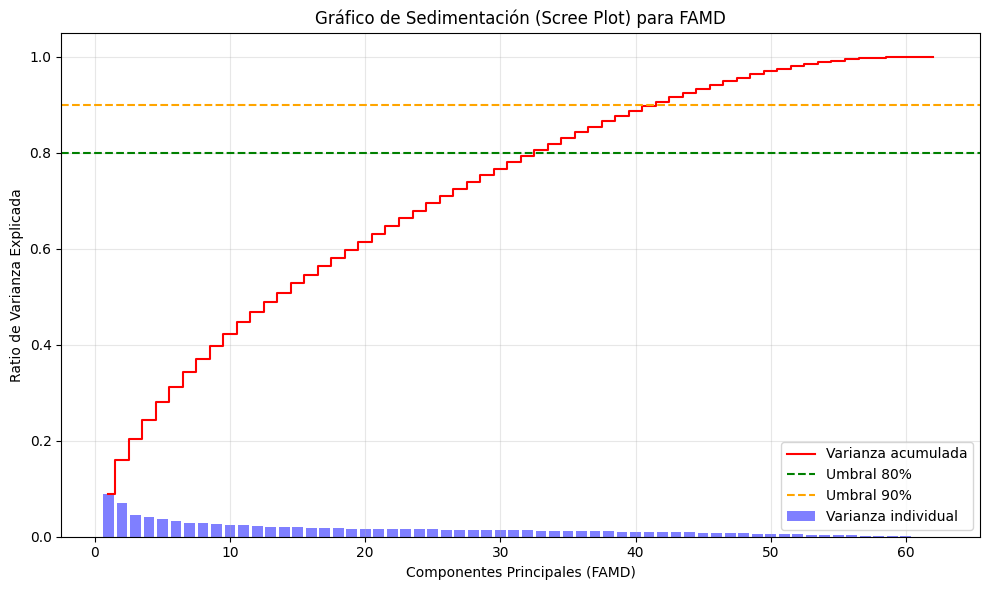

In [ ]:
# 3. Graficamos
plt.figure(figsize=(10, 6))

# Gráfico de barras para la varianza de cada componente individual
plt.bar(range(1, len(varianza_individual) + 1), varianza_individual, alpha=0.5, align='center',
        label='Varianza individual', color='blue')

# Gráfico de línea para la varianza acumulada
plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid',
         label='Varianza acumulada', color='red')

# Añadimos líneas de referencia (ej. 80% y 90% de la información)
plt.axhline(y=0.80, color='g', linestyle='--', label='Umbral 80%')
plt.axhline(y=0.90, color='orange', linestyle='--', label='Umbral 90%')

plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales (FAMD)')
plt.title('Gráfico de Sedimentación (Scree Plot) para FAMD')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Iniciando evaluación exhaustiva (FAMD + KMeans)...

[ Entrenando FAMD con 3 variables ]
Info retenida: 20.3%
  -> Para K=2 | Silhouette Score: 0.2804
  -> Para K=3 | Silhouette Score: 0.3031
  -> Para K=4 | Silhouette Score: 0.2684
  -> Para K=5 | Silhouette Score: 0.2684

[ Entrenando FAMD con 5 variables ]
Info retenida: 28.0%
  -> Para K=2 | Silhouette Score: 0.2273
  -> Para K=3 | Silhouette Score: 0.2218
  -> Para K=4 | Silhouette Score: 0.2004
  -> Para K=5 | Silhouette Score: 0.1693

[ Entrenando FAMD con 7 variables ]
Info retenida: 34.0%
  -> Para K=2 | Silhouette Score: 0.1840
  -> Para K=3 | Silhouette Score: 0.1839
  -> Para K=4 | Silhouette Score: 0.1676
  -> Para K=5 | Silhouette Score: 0.1601

[ Entrenando FAMD con 10 variables ]
Info retenida: 42.1%
  -> Para K=2 | Silhouette Score: 0.1696
  -> Para K=3 | Silhouette Score: 0.1453
  -> Para K=4 | Silhouette Score: 0.1291
  -> Para K=5 | Silhouette Score: 0.1021

[ Entrenando FAMD con 12 variables ]
Info retenida: 46.6%
 

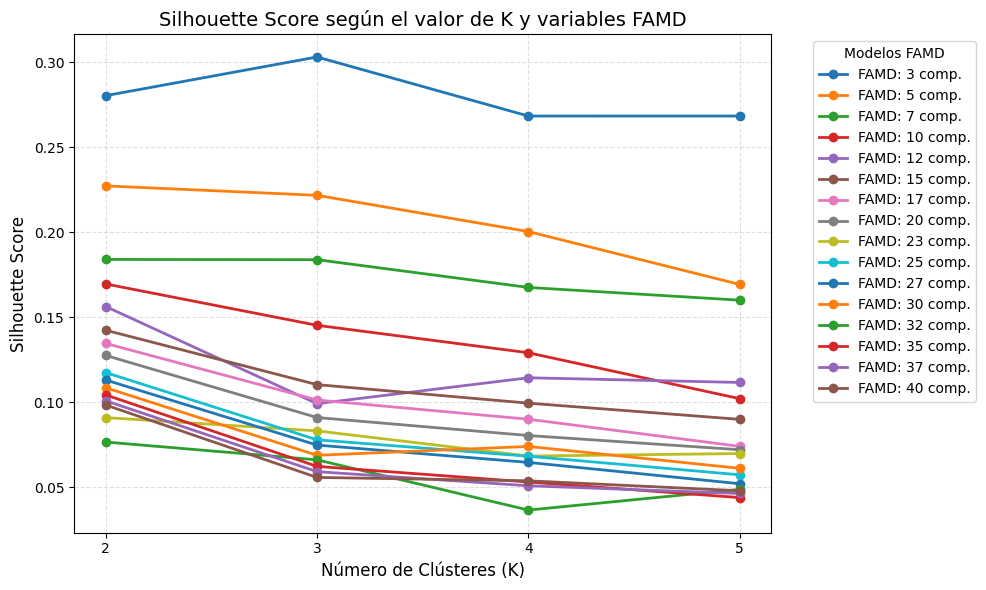

In [ ]:
componentes_a_probar = [3, 5, 7, 10, 12, 15, 17, 20, 23, 25, 27, 30, 32, 35, 37, 40]

rango_k = range(2, 6) # K desde 2 hasta 6 (el 7 no se incluye)

# Diccionario para guardar los resultados y graficarlos luego
resultados_grid = {}

print("Iniciando evaluación exhaustiva (FAMD + KMeans)...")
print("=" * 60)

# Bucle externo: Iteramos sobre el número de componentes FAMD
for n_famd in componentes_a_probar:
    print(f"\n[ Entrenando FAMD con {n_famd} variables ]")
    
    # 1. Aplicar FAMD
    famd_temp = prince.FAMD(n_components=n_famd, random_state=42)
    X_reducido = famd_temp.fit_transform(trainset_no_ohe) 
    
    # 2. Extraer la información retenida (manejo de versiones de prince)
    try:
        varianza_array = np.array(famd_temp.percentage_of_variance_)
        varianza_retenida = varianza_array.sum()
        if varianza_retenida <= 1.5: 
            varianza_retenida *= 100
    except AttributeError:
        varianza_retenida = sum(famd_temp.explained_inertia_) * 100
        
    print(f"Info retenida: {varianza_retenida:.1f}%")
    
    # Lista para guardar los scores de este modelo FAMD
    scores_k = []
    
    # Bucle interno: Iteramos sobre el número de clústeres (K)
    for k in rango_k:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X_reducido)
        
        score = silhouette_score(X_reducido, labels)
        scores_k.append(score)
        
        print(f"  -> Para K={k} | Silhouette Score: {score:.4f}")
        
    # Guardamos los resultados en el diccionario
    resultados_grid[n_famd] = scores_k

print("\n" + "=" * 60)
print("Generando gráfico de resultados...")

# 3. Graficar los resultados
plt.figure(figsize=(10, 6))

# Dibujar una línea por cada valor de componentes FAMD probado
for n_famd, scores in resultados_grid.items():
    plt.plot(list(rango_k), scores, marker='o', linewidth=2, label=f'FAMD: {n_famd} comp.')

plt.title('Silhouette Score según el valor de K y variables FAMD', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(rango_k)) # Asegurar que el eje X muestre solo enteros (2, 3, 4, 5, 6)

# Poner la leyenda fuera del gráfico para que no tape las líneas
plt.legend(title="Modelos FAMD", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

## K-Medioids (CLARA)

CLARA es simplemente el algoritmo PAM ejecutado sobre múltiples muestras aleatorias

In [ ]:
import kmedoids # Nueva librería para PAM
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.spatial.distance as ssd
import prince
import numpy as np
import pandas as pd

from itertools import combinations
import heapq 

In [ ]:
trainset_no_ohe = pd.read_csv("trainset_noOHE.csv")

In [ ]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas = [col for col in cols_categoricas if col in trainset_no_ohe.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas = [col for col in cols_numericas if col in trainset_no_ohe.columns]

trainset_no_ohe[var_numericas] = trainset_no_ohe[var_numericas].astype('float64')
trainset_no_ohe[var_categoricas] = trainset_no_ohe[var_categoricas].astype('object')

print(f"Número de columnas categóricas: {len(var_categoricas)}")
print(var_categoricas)

print(f"Número de columnas numéricas: {len(var_numericas)}")
print(var_numericas)

Número de columnas categóricas: 16
['genero', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 'medicacion_osteoporosis', 'aprueba_cond4', 'tamano_manguito_pa', 'estado_elastografia', 'tipo_sonda_elasto', 'raza_etnia']
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl',

In [ ]:
trainset_no_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1919 entries, 0 to 1918
Data columns (total 62 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   edad_an                         1919 non-null   float64
 1   tamano_hogar                    1919 non-null   float64
 2   psu                             1919 non-null   float64
 3   ratio_pobreza                   1919 non-null   float64
 4   tiempo_seg_cond1                1919 non-null   float64
 5   tiempo_seg_cond2                1919 non-null   float64
 6   tiempo_seg_cond3                1919 non-null   float64
 7   tiempo_seg_cond4                1919 non-null   float64
 8   pulso                           1919 non-null   float64
 9   peso_kg                         1919 non-null   float64
 10  altura_cm                       1919 non-null   float64
 11  imc                             1919 non-null   float64
 12  largo_pierna_superior_cm        19

In [ ]:
print("Calculando la matriz de Distancia de Gower...")
matriz_distancias_gower = gower.gower_matrix(trainset_no_ohe)

Calculando la matriz de Distancia de Gower...


In [ ]:
resultados_pam = {}
mejor_k_pam = -1
mejor_score_pam = -1

for k in range(2, 6):
    # Usamos el algoritmo PAM clásico
    km = kmedoids.KMedoids(n_clusters=k, method='pam', random_state=42)
    c = km.fit(matriz_distancias_gower)
    labels_pam = c.labels_
    
    score_pam = silhouette_score(matriz_distancias_gower, labels_pam, metric='precomputed')
    resultados_pam[k] = score_pam
    print(f"PAM -> Para K={k} | Silhouette Score (Gower): {score_pam:.4f}")
    
    if score_pam > mejor_score_pam:
        mejor_score_pam = score_pam
        mejor_k_pam = k

print(f"🏆 Mejor K para PAM: {mejor_k_pam} (Score: {mejor_score_pam:.4f})")

print("\n" + "="*60)
print("2. EVALUACIÓN CON CLUSTERING JERÁRQUICO AGLOMERATIVO")
print("="*60)

PAM -> Para K=2 | Silhouette Score (Gower): 0.0911
PAM -> Para K=3 | Silhouette Score (Gower): 0.0970
PAM -> Para K=4 | Silhouette Score (Gower): 0.0822
PAM -> Para K=5 | Silhouette Score (Gower): 0.0755
🏆 Mejor K para PAM: 3 (Score: 0.0970)

2. EVALUACIÓN CON CLUSTERING JERÁRQUICO AGLOMERATIVO


### Aplicando reducción de dimensionalidad FAMD


1. EVALUACIÓN EXHAUSTIVA: K-MEDOIDS (PAM) + FAMD (2 a 20 comp.)

[ Entrenando FAMD con  2 variables ]
  -> K=2 | Silhouette: 0.3495
  -> K=3 | Silhouette: 0.3986
  -> K=4 | Silhouette: 0.3729
  -> K=5 | Silhouette: 0.3408

[ Entrenando FAMD con  3 variables ]
  -> K=2 | Silhouette: 0.2747
  -> K=3 | Silhouette: 0.2975
  -> K=4 | Silhouette: 0.2793
  -> K=5 | Silhouette: 0.2618

[ Entrenando FAMD con  4 variables ]
  -> K=2 | Silhouette: 0.2328
  -> K=3 | Silhouette: 0.2536
  -> K=4 | Silhouette: 0.2104
  -> K=5 | Silhouette: 0.2040

[ Entrenando FAMD con  5 variables ]
  -> K=2 | Silhouette: 0.1936
  -> K=3 | Silhouette: 0.2175
  -> K=4 | Silhouette: 0.1831
  -> K=5 | Silhouette: 0.1802

[ Entrenando FAMD con  6 variables ]
  -> K=2 | Silhouette: 0.1794
  -> K=3 | Silhouette: 0.1791
  -> K=4 | Silhouette: 0.1441
  -> K=5 | Silhouette: 0.1606

[ Entrenando FAMD con  7 variables ]
  -> K=2 | Silhouette: 0.1624
  -> K=3 | Silhouette: 0.1727
  -> K=4 | Silhouette: 0.1368
  -> K=5 | Silhou

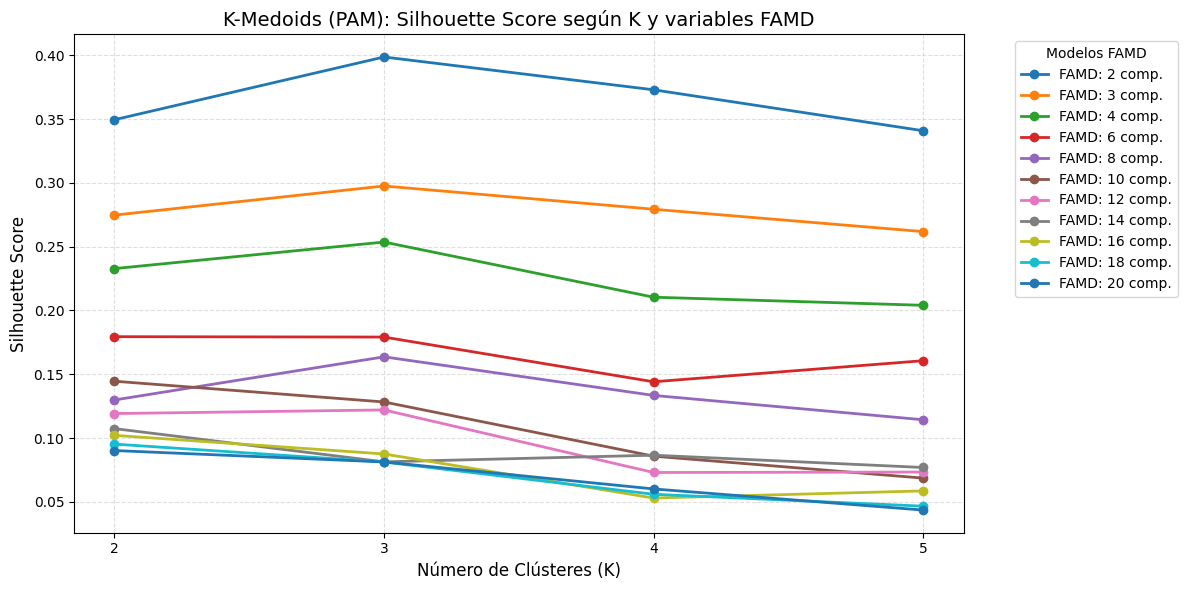

In [ ]:
print("\n" + "="*60)
print("1. EVALUACIÓN EXHAUSTIVA: K-MEDOIDS (PAM) + FAMD (2 a 20 comp.)")
print("="*60)

componentes_famd = list(range(2, 21)) # De 2 a 20
rango_k = range(2, 6) # De 2 a 5

# Diccionario para guardar los resultados y graficarlos
resultados_silhouette_pam = {}

# Variables para guardar el "Campeón Absoluto"
mejor_score_global_pam = -1
mejor_k_global_pam = -1
mejor_famd_global_pam = -1

for n_famd in componentes_famd:
    print(f"\n[ Entrenando FAMD con {n_famd:2d} variables ]")
    
    # 1. Reducir dimensionalidad con FAMD
    famd_temp = prince.FAMD(n_components=n_famd, random_state=42)
    X_famd_continuo = famd_temp.fit_transform(trainset_no_ohe)
    matriz_famd = X_famd_continuo.to_numpy()
    
    scores_sil_k = []
    
    # 2. Iterar sobre K para este nivel de FAMD
    for k in rango_k:
        # Al usar matriz_famd (coordenadas continuas), PAM usará distancia Euclidiana internamente
        km = kmedoids.KMedoids(n_clusters=k, method='pam', metric='euclidean', random_state=42)
        c = km.fit(matriz_famd)
        labels_pam = c.labels_
        
        # OJO: Calculamos el Silhouette sobre la matriz continua de FAMD, ya NO usamos Gower
        score_pam = silhouette_score(matriz_famd, labels_pam, metric='euclidean')
        scores_sil_k.append(score_pam)
        
        print(f"  -> K={k} | Silhouette: {score_pam:.4f}")
        
        # Actualizar el campeón absoluto
        if score_pam > mejor_score_global_pam:
            mejor_score_global_pam = score_pam
            mejor_k_global_pam = k
            mejor_famd_global_pam = n_famd

    # Guardar en diccionario para la gráfica
    resultados_silhouette_pam[n_famd] = scores_sil_k

print("\n" + "="*60)
print(f"🏆 CAMPEÓN ABSOLUTO PAM: FAMD = {mejor_famd_global_pam} comp. | K = {mejor_k_global_pam}")
print(f"   (Silhouette Score: {mejor_score_global_pam:.4f})")
print("="*60)

# ---------------------------------------------------------
# GRAFICAR RESULTADOS (SILHOUETTE)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for n_famd, scores in resultados_silhouette_pam.items():
    # Mostramos líneas pares o el 3 para no saturar el gráfico visualmente
    if n_famd % 2 == 0 or n_famd == 3: 
        plt.plot(list(rango_k), scores, marker='o', linewidth=2, label=f'FAMD: {n_famd} comp.')

plt.title('K-Medoids (PAM): Silhouette Score según K y variables FAMD', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(rango_k))
plt.legend(title="Modelos FAMD", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

## Custering Jerarquico Aglomerativo

### Sin Reducción de dimensionalidad (FAMD)

In [ ]:
matriz_distancias_gower = gower.gower_matrix(trainset_no_ohe)

Jerárquico -> Para K=2 | Silhouette Score (Gower): 0.3110
Jerárquico -> Para K=3 | Silhouette Score (Gower): 0.2218
Jerárquico -> Para K=4 | Silhouette Score (Gower): 0.1944
Jerárquico -> Para K=5 | Silhouette Score (Gower): 0.1684
🏆 Mejor K para Jerárquico: 2 (Score: 0.3110)


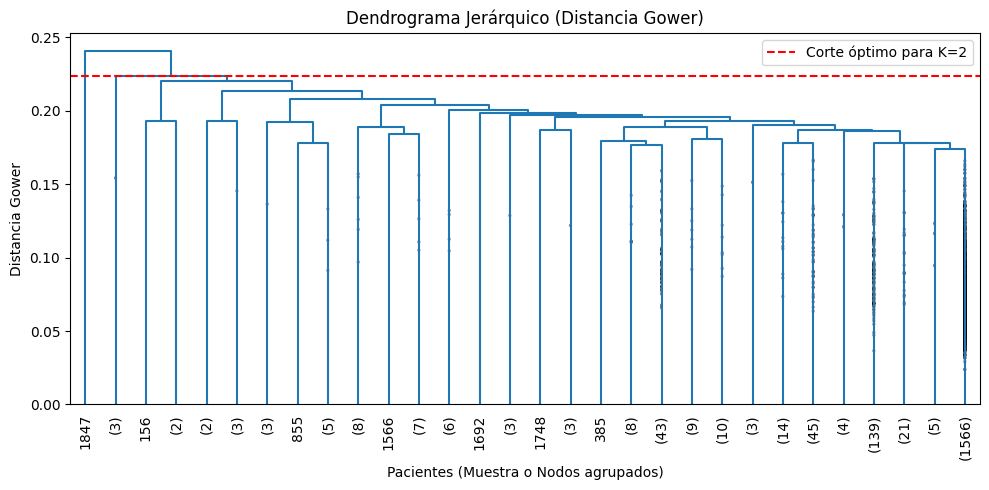

In [ ]:
resultados_jer = {}
mejor_k_jer = -1
mejor_score_jer = -1

for k in range(2, 6):
    # linkage='average' es ideal para distancias no euclidianas como Gower
    jerarquico = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
    labels_jer = jerarquico.fit_predict(matriz_distancias_gower)
    
    score_jer = silhouette_score(matriz_distancias_gower, labels_jer, metric='precomputed')
    resultados_jer[k] = score_jer
    print(f"Jerárquico -> Para K={k} | Silhouette Score (Gower): {score_jer:.4f}")
    
    if score_jer > mejor_score_jer:
        mejor_score_jer = score_jer
        mejor_k_jer = k

print(f"🏆 Mejor K para Jerárquico: {mejor_k_jer} (Score: {mejor_score_jer:.4f})")

# Graficar el Dendrograma
gower_condensada = ssd.squareform(matriz_distancias_gower)
Z = linkage(gower_condensada, method='average')

plt.figure(figsize=(10, 5))
plt.title('Dendrograma Jerárquico (Distancia Gower)')
plt.xlabel('Pacientes (Muestra o Nodos agrupados)')
plt.ylabel('Distancia Gower')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
if mejor_k_jer > 1: # Prevenir error de índice
    plt.axhline(y=Z[-mejor_k_jer, 2], color='r', linestyle='--', label=f'Corte óptimo para K={mejor_k_jer}')
plt.legend()
plt.tight_layout()
plt.show()

Clustering jerarquico CON FAMD


2. EVALUACIÓN EXHAUSTIVA: JERÁRQUICO (WARD) + FAMD (2 a 20 comp.)

[ Entrenando FAMD con  2 variables ]
  -> K=2 | Silhouette: 0.3542
  -> K=3 | Silhouette: 0.3506
  -> K=4 | Silhouette: 0.3408
  -> K=5 | Silhouette: 0.3150

[ Entrenando FAMD con  3 variables ]
  -> K=2 | Silhouette: 0.2402
  -> K=3 | Silhouette: 0.2454
  -> K=4 | Silhouette: 0.2254
  -> K=5 | Silhouette: 0.2247

[ Entrenando FAMD con  4 variables ]
  -> K=2 | Silhouette: 0.2151
  -> K=3 | Silhouette: 0.2139
  -> K=4 | Silhouette: 0.1840
  -> K=5 | Silhouette: 0.1918

[ Entrenando FAMD con  5 variables ]
  -> K=2 | Silhouette: 0.1982
  -> K=3 | Silhouette: 0.1744
  -> K=4 | Silhouette: 0.1793
  -> K=5 | Silhouette: 0.1755

[ Entrenando FAMD con  6 variables ]
  -> K=2 | Silhouette: 0.1476
  -> K=3 | Silhouette: 0.1744
  -> K=4 | Silhouette: 0.1826
  -> K=5 | Silhouette: 0.1853

[ Entrenando FAMD con  7 variables ]
  -> K=2 | Silhouette: 0.1823
  -> K=3 | Silhouette: 0.1388
  -> K=4 | Silhouette: 0.1428
  -> K=5 | Silh

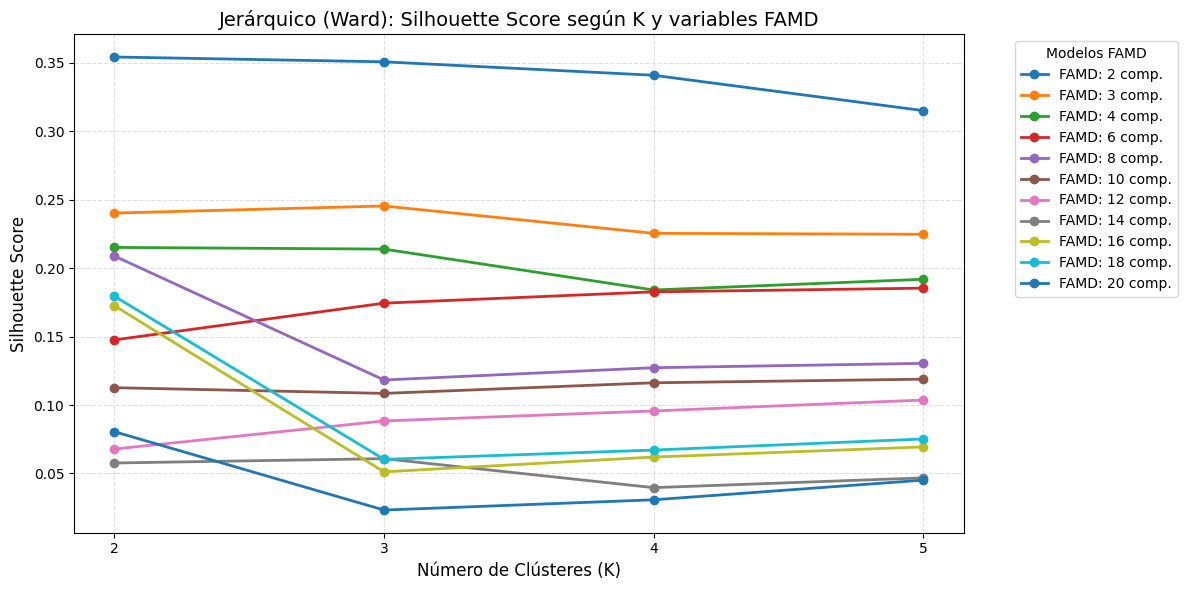


Generando Dendrograma para el modelo óptimo...


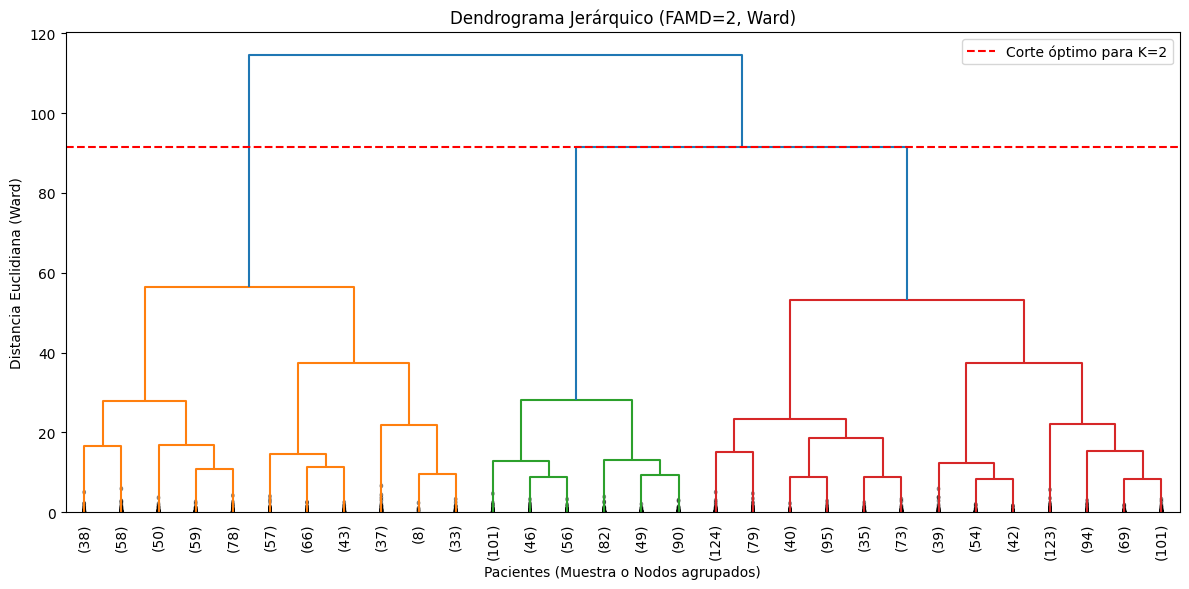

In [ ]:
print("\n" + "="*60)
print("2. EVALUACIÓN EXHAUSTIVA: JERÁRQUICO (WARD) + FAMD (2 a 20 comp.)")
print("="*60)

componentes_famd = list(range(2, 21)) # De 2 a 20
rango_k = range(2, 6) # De 2 a 5

# Diccionario para guardar los resultados (para la gráfica)
resultados_silhouette_jer = {}

# Variables para guardar el "Campeón Absoluto"
mejor_score_global_jer = -1
mejor_k_global_jer = -1
mejor_famd_global_jer = -1

# Variable para guardar las coordenadas FAMD del mejor modelo (para el dendrograma)
mejor_matriz_famd = None 

for n_famd in componentes_famd:
    print(f"\n[ Entrenando FAMD con {n_famd:2d} variables ]")
    
    # 1. Reducir dimensionalidad con FAMD
    famd_temp = prince.FAMD(n_components=n_famd, random_state=42)
    X_famd_continuo = famd_temp.fit_transform(trainset_no_ohe)
    matriz_famd = X_famd_continuo.to_numpy()
    
    scores_sil_k = []
    
    # 2. Iterar sobre K para este nivel de FAMD
    for k in rango_k:
        # Usamos Euclidean y Ward, ideal para el espacio numérico continuo de FAMD
        jer_famd = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
        labels_jer_famd = jer_famd.fit_predict(matriz_famd)
        
        score_jer_famd = silhouette_score(matriz_famd, labels_jer_famd)
        scores_sil_k.append(score_jer_famd)
        
        print(f"  -> K={k} | Silhouette: {score_jer_famd:.4f}")
        
        # Actualizar el campeón absoluto
        if score_jer_famd > mejor_score_global_jer:
            mejor_score_global_jer = score_jer_famd
            mejor_k_global_jer = k
            mejor_famd_global_jer = n_famd
            mejor_matriz_famd = matriz_famd # Guardamos la matriz ganadora para graficar luego

    # Guardar en diccionario para la gráfica
    resultados_silhouette_jer[n_famd] = scores_sil_k

print("\n" + "="*60)
print(f"🏆 CAMPEÓN ABSOLUTO JERÁRQUICO: FAMD = {mejor_famd_global_jer} comp. | K = {mejor_k_global_jer}")
print(f"   (Silhouette Score: {mejor_score_global_jer:.4f})")
print("="*60)

# ---------------------------------------------------------
# GRAFICAR RESULTADOS (SILHOUETTE)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for n_famd, scores in resultados_silhouette_jer.items():
    # Solo mostramos líneas pares o de 5 en 5 para no saturar el gráfico
    if n_famd % 2 == 0 or n_famd == 3: 
        plt.plot(list(rango_k), scores, marker='o', linewidth=2, label=f'FAMD: {n_famd} comp.')

plt.title('Jerárquico (Ward): Silhouette Score según K y variables FAMD', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(rango_k))
plt.legend(title="Modelos FAMD", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRAFICAR EL DENDROGRAMA ÓPTIMO
# ---------------------------------------------------------
print("\nGenerando Dendrograma para el modelo óptimo...")
# Para ward con datos continuos, le pasamos la matriz directamente a linkage
Z_ward = linkage(mejor_matriz_famd, method='ward')

plt.figure(figsize=(12, 6))
plt.title(f'Dendrograma Jerárquico (FAMD={mejor_famd_global_jer}, Ward)')
plt.xlabel('Pacientes (Muestra o Nodos agrupados)')
plt.ylabel('Distancia Euclidiana (Ward)')
# truncate_mode para no colapsar la gráfica
dendrogram(Z_ward, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
if mejor_k_global_jer > 1:
    # Dibujar la línea de corte horizontal
    plt.axhline(y=Z_ward[-mejor_k_global_jer, 2], color='r', linestyle='--', label=f'Corte óptimo para K={mejor_k_global_jer}')
plt.legend()
plt.tight_layout()
plt.show()

## GAUSSIAN MIXTURE MODELS

Aplicando FAMD para reducción de dimensionalidad


3. EVALUACIÓN EXHAUSTIVA: GMM (K=2 a 5) + FAMD (2 a 20 comp.)

[ Entrenando FAMD con  2 variables ]
  -> K=2 | Silhouette: 0.3372 | BIC: 16958
  -> K=3 | Silhouette: 0.3959 | BIC: 16767
  -> K=4 | Silhouette: 0.3668 | BIC: 16779
  -> K=5 | Silhouette: 0.3433 | BIC: 16817

[ Entrenando FAMD con  3 variables ]
  -> K=2 | Silhouette: 0.3001 | BIC: 24281
  -> K=3 | Silhouette: 0.2936 | BIC: 24108
  -> K=4 | Silhouette: 0.2308 | BIC: 24146
  -> K=5 | Silhouette: 0.2457 | BIC: 24161

[ Entrenando FAMD con  4 variables ]
  -> K=2 | Silhouette: 0.2738 | BIC: 30972
  -> K=3 | Silhouette: 0.2360 | BIC: 30794
  -> K=4 | Silhouette: 0.2095 | BIC: 30731
  -> K=5 | Silhouette: 0.1679 | BIC: 30783

[ Entrenando FAMD con  5 variables ]
  -> K=2 | Silhouette: 0.2643 | BIC: 37662
  -> K=3 | Silhouette: 0.1993 | BIC: 37430
  -> K=4 | Silhouette: 0.1873 | BIC: 37405
  -> K=5 | Silhouette: 0.1589 | BIC: 37327

[ Entrenando FAMD con  6 variables ]
  -> K=2 | Silhouette: 0.3079 | BIC: 43084
  -> K=3 | Silho

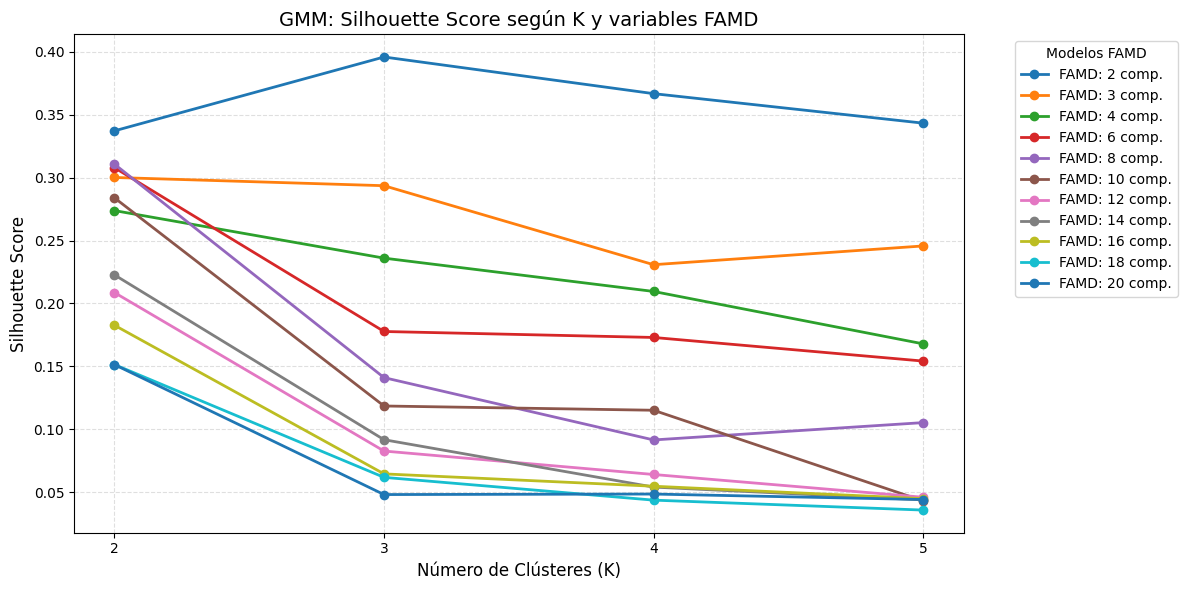

In [ ]:
print("\n" + "="*60)
print("3. EVALUACIÓN EXHAUSTIVA: GMM (K=2 a 5) + FAMD (2 a 20 comp.)")
print("="*60)

componentes_famd = list(range(2, 21)) # De 2 a 20
rango_k = range(2, 6) # De 2 a 5

# Diccionarios para guardar los resultados y graficar después
resultados_silhouette_gmm = {}
resultados_bic_gmm = {}

# Variables para guardar el "Campeón Absoluto"
mejor_score_global = -1
mejor_k_global = -1
mejor_famd_global = -1

for n_famd in componentes_famd:
    print(f"\n[ Entrenando FAMD con {n_famd:2d} variables ]")
    
    # 1. Reducir dimensionalidad
    famd_temp = prince.FAMD(n_components=n_famd, random_state=42)
    X_famd_continuo = famd_temp.fit_transform(trainset_no_ohe)
    matriz_famd = X_famd_continuo.to_numpy()
    
    scores_sil_k = []
    scores_bic_k = []
    
    # 2. Iterar sobre K para este nivel de FAMD
    for k in rango_k:
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
        labels_gmm = gmm.fit_predict(matriz_famd)
        
        score_gmm = silhouette_score(matriz_famd, labels_gmm)
        bic_score = gmm.bic(matriz_famd)
        
        scores_sil_k.append(score_gmm)
        scores_bic_k.append(bic_score)
        
        print(f"  -> K={k} | Silhouette: {score_gmm:.4f} | BIC: {bic_score:.0f}")
        
        # Actualizar el campeón absoluto
        if score_gmm > mejor_score_global:
            mejor_score_global = score_gmm
            mejor_k_global = k
            mejor_famd_global = n_famd

    # Guardar en diccionarios
    resultados_silhouette_gmm[n_famd] = scores_sil_k
    resultados_bic_gmm[n_famd] = scores_bic_k

print("\n" + "="*60)
print(f"🏆 CAMPEÓN ABSOLUTO GMM: FAMD = {mejor_famd_global} comp. | K = {mejor_k_global}")
print(f"   (Silhouette Score: {mejor_score_global:.4f})")
print("="*60)

# ---------------------------------------------------------
# GRAFICAR RESULTADOS (SILHOUETTE)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for n_famd, scores in resultados_silhouette_gmm.items():
    # Solo mostramos líneas pares o de 5 en 5 para no saturar el gráfico
    if n_famd % 2 == 0 or n_famd == 3: 
        plt.plot(list(rango_k), scores, marker='o', linewidth=2, label=f'FAMD: {n_famd} comp.')

plt.title('GMM: Silhouette Score según K y variables FAMD', fontsize=14)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(rango_k))
plt.legend(title="Modelos FAMD", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
#comando de LIMPIEZA DE KERNEL PARA EVITAR QUE SE MEZCLEN VARIBALES DE DISTINTAS PRUEBAS
%reset -f
%reset -f in out dhist

Flushing input history
Flushing output cache (0 entries)
Flushing directory history


## Busqueda de las variables más relevantes

En vista de que ninguno de los resultados es suficientemente bueno, se va a ejecutar una prueba de importancia de variables aplicando k-means a todas las posibles combinaciones de variables.

In [2]:
import pandas as pd
from sklearn.cluster import KMeans
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import unicodedata
import re
import gower

import kmedoids # Nueva librería para PAM
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.spatial.distance as ssd
import prince
import numpy as np

from itertools import combinations
import heapq 

In [3]:
trainset_no_ohe = pd.read_csv("trainset_noOHE.csv")

In [4]:
trainset_no_ohe.head()

print(trainset_no_ohe.shape)

(1919, 62)


In [5]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas = [col for col in cols_categoricas if col in trainset_no_ohe.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas = [col for col in cols_numericas if col in trainset_no_ohe.columns]

trainset_no_ohe[var_numericas] = trainset_no_ohe[var_numericas].astype('float64')
trainset_no_ohe[var_categoricas] = trainset_no_ohe[var_categoricas].astype('object')

print(f"Número de columnas categóricas: {len(var_categoricas)}")
print(var_categoricas)

print(f"Número de columnas numéricas: {len(var_numericas)}")
print(var_numericas)

Número de columnas categóricas: 16
['genero', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 'medicacion_osteoporosis', 'aprueba_cond4', 'tamano_manguito_pa', 'estado_elastografia', 'tipo_sonda_elasto', 'raza_etnia']
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl',

In [6]:
    
var_num = trainset_no_ohe.select_dtypes(include=['number'])
var_num.shape

(1919, 46)

In [7]:
var_num.head(10)

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,plaquetas_totales,volumen_plaquetario_medio,trigliceridos_mmol_l,ldl_martin_mmol_l,hdl_mmol_l,plomo_sangre_umol_l,cadmio_sangre_nmol_l,mercurio_sangre_nmol_l,selenio_sangre_umol_l,manganeso_sangre_nmol_l
0,-0.188751,1.575278,1.021598,0.984181,0.144067,0.245103,0.162136,0.810059,-0.438261,1.282766,...,-0.148788,-0.064880,-0.253993,0.564297,0.931707,-0.485349,-0.286241,0.286165,0.271704,-0.024538
1,0.575265,0.208042,1.021598,-0.578577,0.144067,0.245103,0.162136,0.810059,0.158633,1.859173,...,1.324984,-1.395746,2.736229,-0.674377,-1.007353,-0.429424,0.395955,-0.564023,-0.514788,-1.792289
2,-0.049839,0.208042,1.021598,1.226568,0.144067,0.245103,0.162136,0.810059,-0.352991,0.254454,...,-1.146655,0.933270,-0.483653,0.004270,-0.024542,-0.429424,-0.184990,-0.322245,0.244583,1.214156
3,-0.605487,1.575278,-0.978858,0.021012,0.144067,0.245103,0.162136,0.810059,0.840797,-0.086779,...,-0.440472,0.489648,-0.191021,1.921592,-0.024542,0.031964,-0.321788,0.646851,0.217463,-0.419084
4,1.200370,0.208042,1.021598,0.250642,0.144067,0.245103,0.162136,-1.268443,2.716750,-0.294286,...,-0.302306,-1.395746,0.854491,-1.470505,0.666082,1.360202,4.937467,7.921013,3.010867,0.591839
5,-1.508416,-0.475576,-0.978858,1.226568,0.144067,0.245103,0.162136,0.810059,-0.182450,-1.520881,...,-0.102733,1.376892,-0.766099,-1.323370,1.675456,31.825777,-0.030417,-0.529342,0.841233,1.550274
6,1.408738,-1.159194,-0.978858,-0.412733,0.144067,0.245103,0.162136,0.810059,-1.802591,0.120728,...,-0.271603,0.156931,-0.504953,-0.762202,0.453583,0.059927,0.339039,-0.272700,-0.460548,0.545130
7,-1.091680,1.575278,1.021598,-1.292981,0.144067,0.245103,0.162136,0.810059,-1.120426,0.019280,...,0.588098,-0.619407,0.239568,0.291392,-0.432187,-0.051925,-0.380502,-0.524387,0.244583,-0.538828
8,0.366897,0.891660,-0.978858,1.226568,0.144067,0.245103,0.162136,0.054240,0.158633,0.480406,...,-0.087381,-0.952124,2.203749,-0.142865,-1.060478,-0.163776,-0.401870,-0.277654,-0.487668,-1.213793
9,-0.605487,-1.159194,-0.978858,1.226568,0.144067,0.245103,0.162136,-1.835307,-1.717320,-0.796913,...,-0.732157,-0.064880,-0.744800,-1.027958,-0.316729,0.213723,-0.490739,0.805394,1.085316,-1.505930


In [7]:
# print("=" * 80)
# print("BÚSQUEDA EXHAUSTIVA DE COMBINACIONES DE VARIABLES (FUERZA BRUTA)")
# print("=" * 80)

# rango_k = range(2, 6) 
# columnas_disponibles = var_num.columns.tolist()
# total_vars = len(columnas_disponibles)

# campeon_score = -1
# campeon_k = -1
# campeon_variables = ()
# mejores_por_k = {k: {'score': -1, 'variables': ()} for k in rango_k}

# # Nueva variable: Una lista donde heapq mantendrá los Top 20 resultados
# top_20_resultados = []

# for tamano_combinacion in range(2, total_vars + 1):
#     combinaciones_posibles = list(combinations(columnas_disponibles, tamano_combinacion))
#     total_combs = len(combinaciones_posibles)
    
#     print(f"\n[ Analizando grupos de {tamano_combinacion} variables -> {total_combs} combinaciones posibles ]")
    
#     for i, combo in enumerate(combinaciones_posibles):
#         X_subset = var_num[list(combo)]
        
#         if i % 100 == 0 and i > 0:
#             print(f"  ... Evaluadas {i}/{total_combs} combinaciones de tamaño {tamano_combinacion}")
            
#         for k in rango_k:
#             kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
#             labels = kmeans.fit_predict(X_subset)
#             score = silhouette_score(X_subset, labels)
            
#             # 1. Actualizar el Top 20 usando heapq
#             # Guardamos una tupla con (score, k, combo). Heapq ordena por el primer valor (el score).
#             tupla_resultado = (score, k, combo)
#             if len(top_20_resultados) < 20:
#                 heapq.heappush(top_20_resultados, tupla_resultado)
#             else:
#                 # Si el nuevo score es mayor que el peor de los 20 mejores (que es top_20_resultados[0][0])
#                 # lo sustituye y reordena automáticamente
#                 heapq.heappushpop(top_20_resultados, tupla_resultado)
            
#             # 2. Actualizar campeón por K
#             if score > mejores_por_k[k]['score']:
#                 mejores_por_k[k]['score'] = score
#                 mejores_por_k[k]['variables'] = combo
                
#             # 3. Actualizar campeón global
#             if score > campeon_score:
#                 campeon_score = score
#                 campeon_k = k
#                 campeon_variables = combo

# print("\n" + "=" * 80)
# print("🏆 RESULTADOS FINALES DE LA BÚSQUEDA EXHAUSTIVA 🏆")
# print("=" * 80)

# print(f"\nEL CAMPEÓN ABSOLUTO:")
# print(f"  -> K Óptimo: {campeon_k}")
# print(f"  -> Silhouette Score: {campeon_score:.4f}")
# print(f"  -> Variables usadas ({len(campeon_variables)}): {', '.join(campeon_variables)}")

# print("\n--- MEJORES COMBINACIONES POR CADA K ---")
# for k in rango_k:
#     m_score = mejores_por_k[k]['score']
#     m_vars = mejores_por_k[k]['variables']
#     print(f"\nPara K={k}:")
#     print(f"  -> Silhouette Score: {m_score:.4f}")
#     print(f"  -> Variables ({len(m_vars)}): {', '.join(m_vars)}")

# print("\n" + "=" * 80)
# print("🌟 TOP 20 MEJORES COMBINACIONES GLOBALES 🌟")
# print("=" * 80)

# # heapq guarda los datos como un árbol binario. Para imprimirlos del mejor al peor,
# # ordenamos la lista de mayor a menor y la recorremos.
# top_20_ordenado = sorted(top_20_resultados, reverse=True)

# for i, (score, k, combo) in enumerate(top_20_ordenado, 1):
#     print(f"\nPosición #{i}:")
#     print(f"  -> Silhouette Score: {score:.4f} | K = {k}")
#     print(f"  -> N Variables: {len(combo)}")
#     print(f"  -> Variables: {', '.join(combo)}")

In [8]:
# import pandas as pd
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score
# from itertools import combinations
# import heapq 

# print("=" * 80)
# print("BÚSQUEDA EXHAUSTIVA DE COMBINACIONES DE VARIABLES (FUERZA BRUTA)")
# print("=" * 80)

# rango_k = range(2, 6) 
# columnas_disponibles = var_num.columns.tolist()

# # --- AQUÍ ESTÁ EL CAMBIO CLAVE ---
# max_variables_agrupadas = 3 # El techo máximo de variables a combinar
# # ---------------------------------

# campeon_score = -1
# campeon_k = -1
# campeon_variables = ()
# mejores_por_k = {k: {'score': -1, 'variables': ()} for k in rango_k}

# # Nueva variable: Una lista donde heapq mantendrá los Top 20 resultados
# top_20_resultados = []

# # El bucle ahora va desde 2 hasta max_variables_agrupadas + 1 (para que incluya el 8)
# for tamano_combinacion in range(2, max_variables_agrupadas + 1):
#     combinaciones_posibles = list(combinations(columnas_disponibles, tamano_combinacion))
#     total_combs = len(combinaciones_posibles)
    
#     print(f"\n[ Analizando grupos de {tamano_combinacion} variables -> {total_combs} combinaciones posibles ]")
    
#     for i, combo in enumerate(combinaciones_posibles):
#         X_subset = var_num[list(combo)]
        
#         # He subido el print de progreso a cada 10,000 para que no te sature la pantalla
#         if i % 10000 == 0 and i > 0:
#             print(f"  ... Evaluadas {i}/{total_combs} combinaciones de tamaño {tamano_combinacion}")
            
#         for k in rango_k:
#             kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
#             labels = kmeans.fit_predict(X_subset)
#             score = silhouette_score(X_subset, labels)
            
#             # 1. Actualizar el Top 20 usando heapq
#             tupla_resultado = (score, k, combo)
#             if len(top_20_resultados) < 20:
#                 heapq.heappush(top_20_resultados, tupla_resultado)
#             else:
#                 heapq.heappushpop(top_20_resultados, tupla_resultado)
            
#             # 2. Actualizar campeón por K
#             if score > mejores_por_k[k]['score']:
#                 mejores_por_k[k]['score'] = score
#                 mejores_por_k[k]['variables'] = combo
                
#             # 3. Actualizar campeón global
#             if score > campeon_score:
#                 campeon_score = score
#                 campeon_k = k
#                 campeon_variables = combo

# print("\n" + "=" * 80)
# print("🏆 RESULTADOS FINALES DE LA BÚSQUEDA EXHAUSTIVA 🏆")
# print("=" * 80)

# print(f"\nEL CAMPEÓN ABSOLUTO:")
# print(f"  -> K Óptimo: {campeon_k}")
# print(f"  -> Silhouette Score: {campeon_score:.4f}")
# print(f"  -> Variables usadas ({len(campeon_variables)}): {', '.join(campeon_variables)}")

# print("\n--- MEJORES COMBINACIONES POR CADA K ---")
# for k in rango_k:
#     m_score = mejores_por_k[k]['score']
#     m_vars = mejores_por_k[k]['variables']
#     print(f"\nPara K={k}:")
#     print(f"  -> Silhouette Score: {m_score:.4f}")
#     print(f"  -> Variables ({len(m_vars)}): {', '.join(m_vars)}")

# print("\n" + "=" * 80)
# print("🌟 TOP 20 MEJORES COMBINACIONES GLOBALES 🌟")
# print("=" * 80)

# top_20_ordenado = sorted(top_20_resultados, reverse=True)

# for i, (score, k, combo) in enumerate(top_20_ordenado, 1):
#     print(f"\nPosición #{i}:")
#     print(f"  -> Silhouette Score: {score:.4f} | K = {k}")
#     print(f"  -> N Variables: {len(combo)}")
#     print(f"  -> Variables: {', '.join(combo)}")

Para la busqueda de las variables más relevantes, el metodo de fuerza bruta, probando todas las posibles combinaciones de variables es computacionalmente inviable que que se deberian probar combinaciones del orden de los 10 billones. 

por tanto utilizamos el método de forward selecion que funciona construyendo la combinación ideal paso a paso en lugar de probar todo a ciegas:

1. Prueba las 46 variables de una en una y encuentra la que da el mejor clúster. (46 pruebas).

2. Fija esa variable ganadora y prueba a añadirle una segunda variable de entre las 45 restantes. (45 pruebas).

3. Encuentra la mejor pareja. La fija, y busca la mejor tercera variable añadiendo una de las 44 restantes. (44 pruebas).

In [7]:
print("=" * 80)
print("FORWARD SELECTION")
print("=" * 80)

rango_k = range(2, 6) # K=2, 3, 4, 5
max_variables = 10    # Límite máximo de variables a agrupar
columnas_totales = var_num.columns.tolist()

resultados_finales = {}
campeon_global_score = -1
campeon_global_k = -1
campeon_global_vars = []

for k in rango_k:
    print(f"\n[ Iniciando búsqueda para K={k} ]")
    
    columnas_disponibles = columnas_totales.copy()
    variables_seleccionadas = []
    
    # --- PASO 1: Buscar el mejor PAR inicial (La base sólida) ---
    mejor_score_par = -1
    mejor_par = ()
    
    # Probamos las 1035 parejas posibles
    for combo in combinations(columnas_disponibles, 2):
        X_subset = var_num[list(combo)]
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(X_subset)
        score = silhouette_score(X_subset, labels)
        
        if score > mejor_score_par:
            mejor_score_par = score
            mejor_par = combo
            
    # Fijamos el mejor par y lo sacamos de las disponibles
    variables_seleccionadas.extend(mejor_par)
    for var in mejor_par:
        columnas_disponibles.remove(var)
        
    print(f"  -> Mejor par inicial: {mejor_par} (Score: {mejor_score_par:.4f})")
    
    # Guardamos el historial para ver en qué momento el score hace "pico"
    historial_scores = [mejor_score_par]
    
    # --- PASO 2: Forward Selection (Añadir 1 a 1 hasta max_variables) ---
    for paso in range(3, max_variables + 1):
        mejor_score_paso = -1
        mejor_variable_paso = None
        
        # Probamos a añadir cada una de las variables que quedan libres
        for var_candidata in columnas_disponibles:
            features_a_probar = variables_seleccionadas + [var_candidata]
            X_subset = var_num[features_a_probar]
            
            kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
            labels = kmeans.fit_predict(X_subset)
            score = silhouette_score(X_subset, labels)
            
            if score > mejor_score_paso:
                mejor_score_paso = score
                mejor_variable_paso = var_candidata
                
        # Consolidamos la variable ganadora de este paso
        variables_seleccionadas.append(mejor_variable_paso)
        columnas_disponibles.remove(mejor_variable_paso)
        historial_scores.append(mejor_score_paso)
        
        print(f"  -> + Variable {paso}: '{mejor_variable_paso}' | Nuevo Score: {mejor_score_paso:.4f}")

    # --- PASO 3: Encontrar el pico máximo para este K ---
    # Es posible que el score baje al añadir la 5ª variable. 
    # Nos quedamos con el mejor momento de la historia.
    indice_mejor_momento = historial_scores.index(max(historial_scores))
    score_pico = historial_scores[indice_mejor_momento]
    
    # El índice 0 equivale a 2 variables, índice 1 a 3 variables, etc.
    vars_en_pico = variables_seleccionadas[:indice_mejor_momento + 2]
    
    resultados_finales[k] = {
        'score': score_pico,
        'variables': vars_en_pico
    }
    
    # Actualizar campeón global absoluto
    if score_pico > campeon_global_score:
        campeon_global_score = score_pico
        campeon_global_k = k
        campeon_global_vars = vars_en_pico

print("\n" + "=" * 80)
print("🏆 RESULTADOS FINALES: FORWARD SELECTION 🏆")
print("=" * 80)

print(f"\n🌟 EL CAMPEÓN ABSOLUTO:")
print(f"  -> K Óptimo: {campeon_global_k}")
print(f"  -> Silhouette Score Máximo: {campeon_global_score:.4f}")
print(f"  -> Variables óptimas ({len(campeon_global_vars)}): {', '.join(campeon_global_vars)}")

print("\n--- MEJOR COMBINACIÓN ENCONTRADA PARA CADA K ---")
for k in rango_k:
    res = resultados_finales[k]
    print(f"\nPara K={k}:")
    print(f"  -> Silhouette Score: {res['score']:.4f}")
    print(f"  -> N Variables: {len(res['variables'])}")
    print(f"  -> Variables: {', '.join(res['variables'])}")

FORWARD SELECTION

[ Iniciando búsqueda para K=2 ]


KeyboardInterrupt: 

In [ ]:
print("=" * 80)
print("FORWARD SELECTION")
print("=" * 80)

rango_k = range(2, 6) # K=2, 3, 4, 5
max_variables = 20    # Límite máximo de variables a agrupar
columnas_totales = var_num.columns.tolist()

resultados_finales = {}
campeon_global_score = -1
campeon_global_k = -1
campeon_global_vars = []

for k in rango_k:
    print(f"\n[ Iniciando búsqueda para K={k} ]")
    
    columnas_disponibles = columnas_totales.copy()
    variables_seleccionadas = []
    
    # --- PASO 1: Buscar el mejor PAR inicial (La base sólida) ---
    mejor_score_par = -1
    mejor_par = ()
    
    # Probamos las 1035 parejas posibles
    for combo in combinations(columnas_disponibles, 2):
        X_subset = var_num[list(combo)]
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(X_subset)
        score = silhouette_score(X_subset, labels)
        
        if score > mejor_score_par:
            mejor_score_par = score
            mejor_par = combo
            
    # Fijamos el mejor par y lo sacamos de las disponibles
    variables_seleccionadas.extend(mejor_par)
    for var in mejor_par:
        columnas_disponibles.remove(var)
        
    print(f"  -> Mejor par inicial: {mejor_par} (Score: {mejor_score_par:.4f})")
    
    # Guardamos el historial para ver en qué momento el score hace "pico"
    historial_scores = [mejor_score_par]
    
    # --- PASO 2: Forward Selection (Añadir 1 a 1 hasta max_variables) ---
    for paso in range(3, max_variables + 1):
        mejor_score_paso = -1
        mejor_variable_paso = None
        
        # Probamos a añadir cada una de las variables que quedan libres
        for var_candidata in columnas_disponibles:
            features_a_probar = variables_seleccionadas + [var_candidata]
            X_subset = var_num[features_a_probar]
            
            kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
            labels = kmeans.fit_predict(X_subset)
            score = silhouette_score(X_subset, labels)
            
            if score > mejor_score_paso:
                mejor_score_paso = score
                mejor_variable_paso = var_candidata
                
        # Consolidamos la variable ganadora de este paso
        variables_seleccionadas.append(mejor_variable_paso)
        columnas_disponibles.remove(mejor_variable_paso)
        historial_scores.append(mejor_score_paso)
        
        print(f"  -> + Variable {paso}: '{mejor_variable_paso}' | Nuevo Score: {mejor_score_paso:.4f}")

    # --- PASO 3: Encontrar el pico máximo para este K ---
    # Es posible que el score baje al añadir la 5ª variable. 
    # Nos quedamos con el mejor momento de la historia.
    indice_mejor_momento = historial_scores.index(max(historial_scores))
    score_pico = historial_scores[indice_mejor_momento]
    
    # El índice 0 equivale a 2 variables, índice 1 a 3 variables, etc.
    vars_en_pico = variables_seleccionadas[:indice_mejor_momento + 2]
    
    resultados_finales[k] = {
        'score': score_pico,
        'variables': vars_en_pico
    }
    
    # Actualizar campeón global absoluto
    if score_pico > campeon_global_score:
        campeon_global_score = score_pico
        campeon_global_k = k
        campeon_global_vars = vars_en_pico

print("\n" + "=" * 80)
print("🏆 RESULTADOS FINALES: FORWARD SELECTION 🏆")
print("=" * 80)

print(f"\n🌟 EL CAMPEÓN ABSOLUTO:")
print(f"  -> K Óptimo: {campeon_global_k}")
print(f"  -> Silhouette Score Máximo: {campeon_global_score:.4f}")
print(f"  -> Variables óptimas ({len(campeon_global_vars)}): {', '.join(campeon_global_vars)}")

print("\n--- MEJOR COMBINACIÓN ENCONTRADA PARA CADA K ---")
for k in rango_k:
    res = resultados_finales[k]
    print(f"\nPara K={k}:")
    print(f"  -> Silhouette Score: {res['score']:.4f}")
    print(f"  -> N Variables: {len(res['variables'])}")
    print(f"  -> Variables: {', '.join(res['variables'])}")

FORWARD SELECTION

[ Iniciando búsqueda para K=2 ]
  -> Mejor par inicial: ('rigidez_iqr', 'ratio_iqr_mediana') (Score: 0.9764)
  -> + Variable 3: 'ratio_albumina_creatinina' | Nuevo Score: 0.9689
  -> + Variable 4: 'albumina_orina_mg_l' | Nuevo Score: 0.9642
  -> + Variable 5: 'tiempo_seg_cond3' | Nuevo Score: 0.9572
  -> + Variable 6: 'plomo_sangre_umol_l' | Nuevo Score: 0.9478
  -> + Variable 7: 'tiempo_seg_cond2' | Nuevo Score: 0.9387
  -> + Variable 8: 'rigidez_mediana_kpa' | Nuevo Score: 0.9299
  -> + Variable 9: 'medidas_validas_elasto' | Nuevo Score: 0.9197
  -> + Variable 10: 'ancho_distribucion_eritrocitos' | Nuevo Score: 0.9071
  -> + Variable 11: 'cadmio_sangre_nmol_l' | Nuevo Score: 0.8979
  -> + Variable 12: 'linfocitos_abs' | Nuevo Score: 0.7731
  -> + Variable 13: 'trigliceridos_mmol_l' | Nuevo Score: 0.7093
  -> + Variable 14: 'leucocitos_totales' | Nuevo Score: 0.7228
  -> + Variable 15: 'proteina_c_reactiva_mg_l' | Nuevo Score: 0.7267
  -> + Variable 16: 'eosinofilos

Al observar las variables más relevantes vemos que algunas no tienen demasiado sentido clinico por ejemplo la variable psu (Unidad Primaria de Muestreo), que es un pseudo-estrato utilizado para enmascarar la varianza muestral por motivos de privacidad. No tiene absolutamente ningún valor clínico o biológico, por lo que cualquier clúster basado en ella será un artefacto estadístico.

Tambiénj aunque se hizo un estudio preveio de correlación estaba más enfocado en eliminar variables redundantes como mediciones representadas en distintas unidades.

Denido a que en K-Means, si metes dos variables muy correlacionadas, es como darle "dos votos" a una misma característica biológica, sesgando el clúster hacia esa dirección. Se va a realizar un estudio de correlaciones y simplificar aquellas con más de 0.8 de correlación.

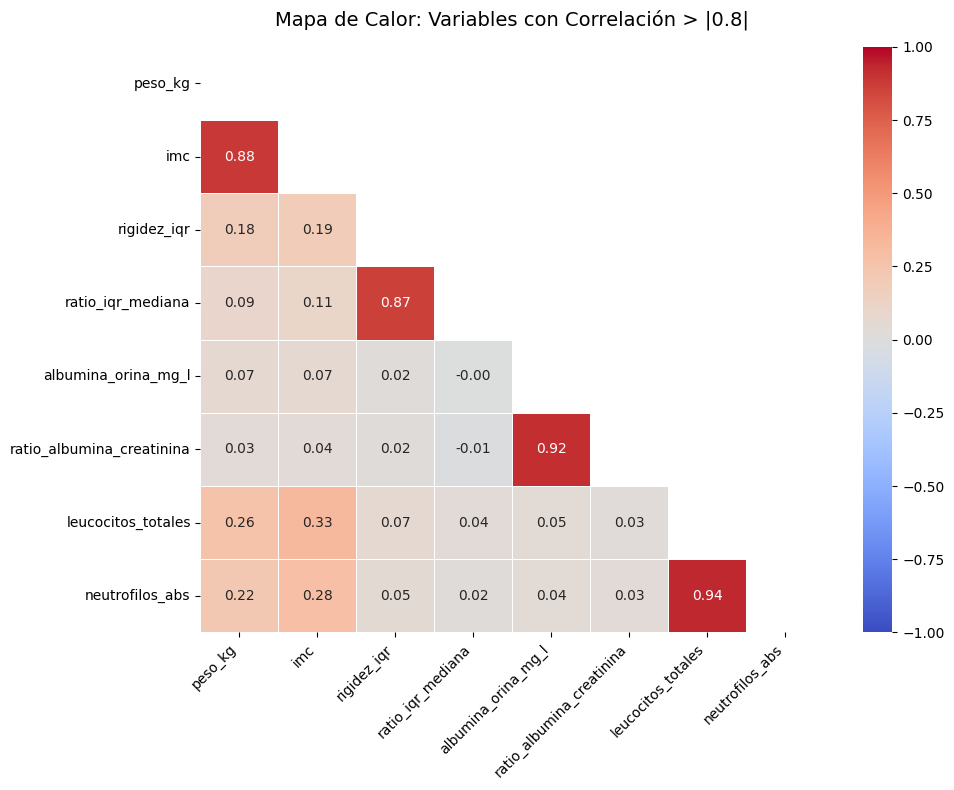

In [8]:
corr_matrix = var_num.corr()

high_corr_mask = (corr_matrix.abs() > 0.8) & (corr_matrix != 1.0)

# 3. Identificar qué columnas tienen al menos una correlación alta
cols_to_keep = high_corr_mask.any()
high_corr_vars = cols_to_keep[cols_to_keep].index

# 4. Filtrar la matriz de correlación para mostrar solo estas variables problemáticas
filtered_corr_matrix = corr_matrix.loc[high_corr_vars, high_corr_vars]

# 5. Configurar y dibujar el mapa de calor
plt.figure(figsize=(10, 8)) # Ajusta el tamaño si es necesario
sns.heatmap(filtered_corr_matrix, 
            annot=True,            # Muestra el valor numérico en cada celda
            cmap='coolwarm',       # Paleta divergente: rojo (positivo), azul (negativo)
            vmin=-1, vmax=1,       # Fija los límites de la escala de color
            center=0,              # Centra el color neutro en el 0
            fmt=".2f",             # Muestra solo 2 decimales
            linewidths=0.5,        # Líneas de separación entre celdas
            mask=np.triu(np.ones_like(filtered_corr_matrix, dtype=bool))) # Opcional: oculta el triángulo superior para no duplicar info

plt.title('Mapa de Calor: Variables con Correlación > |0.8|', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
columnas_a_eliminar = ['peso_kg', 'albumina_orina_mg_l', 'neutrofilos_abs']

# Utilizamos el método .drop() especificando que queremos eliminar columnas
var_num = var_num.drop(columns=columnas_a_eliminar)
var_num.shape

(1919, 43)

Se van a eliminar también variables de control de calidad de las pruebas médicas como son:

1. rigidez_iqr y ratio_iqr_mediana: Son medidas de la desviación/control de calidad de los disparos del FibroScan, no la enfermedad del hígado en sí
2. medidas_validas_elasto e intentos_totales_elasto no son variables biológicas, es el conteo de cuántas veces el técnico disparó el escaner.

In [10]:
columnas_a_eliminar = ['rigidez_iqr', 'ratio_iqr_mediana','medidas_validas_elasto','intentos_totales_elasto'] 
# Utilizamos el método .drop() especificando que queremos eliminar columnas
var_num = var_num.drop(columns=columnas_a_eliminar)
var_num.shape

(1919, 39)

Para las varaiables 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4':

Se observa una falta de varianza. estas son variables que miden el equilibrio de diferentes formas. La inmensa mayoría de las personas adultas que pueden caminar pasan las condiciones 1 y 2. Esto significa que en tu dataset, esas dos columnas estarán llenas con el mismo valor lo que resulta en una variable sin varianza que no aporta ninguna información para separar grupos.

In [11]:
condiciones = ['tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4']

print("--- DIAGNÓSTICO DE VARIANZA Y EFECTO TECHO ---\n")

for col in condiciones:
    if col in var_num.columns:
        # Calcular varianza
        varianza = var_num[col].var()
        
        # Encontrar el valor máximo (el "techo" de la prueba)
        max_val = var_num[col].max()
        
        # Contar cuántos pacientes lograron ese valor máximo
        num_max_vals = (var_num[col] == max_val).sum()
        pct_max_vals = (num_max_vals / len(var_num)) * 100
        
        print(f"Variable: {col}")
        print(f"  Varianza: {varianza:.4f}")
        print(f"  Valor Máximo ('Techo'): {max_val} segundos")
        print(f"  Pacientes en el techo: {num_max_vals} ({pct_max_vals:.1f}% del total)\n")
    else:
        print(f"La columna {col} no se encuentra en el DataFrame.\n")

--- DIAGNÓSTICO DE VARIANZA Y EFECTO TECHO ---

Variable: tiempo_seg_cond1
  Varianza: 1.0005
  Valor Máximo ('Techo'): 0.1440674418393514 segundos
  Pacientes en el techo: 1652 (86.1% del total)

Variable: tiempo_seg_cond2
  Varianza: 1.0005
  Valor Máximo ('Techo'): 0.2451034271325411 segundos
  Pacientes en el techo: 1632 (85.0% del total)

Variable: tiempo_seg_cond3
  Varianza: 1.0005
  Valor Máximo ('Techo'): 0.1621364881979306 segundos
  Pacientes en el techo: 1615 (84.2% del total)

Variable: tiempo_seg_cond4
  Varianza: 1.0005
  Valor Máximo ('Techo'): 0.8100591789827326 segundos
  Pacientes en el techo: 1006 (52.4% del total)



In [12]:
columnas_a_eliminar = ['tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3']

# Utilizamos el método .drop() especificando que queremos eliminar columnas
var_num = var_num.drop(columns=columnas_a_eliminar)
var_num.shape

(1919, 36)

se elimina tambien la variable estadistica de psu varianza.

In [13]:
columnas_a_eliminar = ['psu']

# Utilizamos el método .drop() especificando que queremos eliminar columnas
var_num = var_num.drop(columns=columnas_a_eliminar)
var_num.shape

(1919, 35)

In [14]:
print("=" * 80)
print("FORWARD SELECTION")
print("=" * 80)

rango_k = range(2, 6) # K=2, 3, 4, 5
max_variables = 20    # Límite máximo de variables a agrupar
columnas_totales = var_num.columns.tolist()

resultados_finales = {}
campeon_global_score = -1
campeon_global_k = -1
campeon_global_vars = []

for k in rango_k:
    print(f"\n[ Iniciando búsqueda para K={k} ]")
    
    columnas_disponibles = columnas_totales.copy()
    variables_seleccionadas = []
    
    # --- PASO 1: Buscar el mejor PAR inicial (La base sólida) ---
    mejor_score_par = -1
    mejor_par = ()
    
    # Probamos las 1035 parejas posibles
    for combo in combinations(columnas_disponibles, 2):
        X_subset = var_num[list(combo)]
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(X_subset)
        score = silhouette_score(X_subset, labels)
        
        if score > mejor_score_par:
            mejor_score_par = score
            mejor_par = combo
            
    # Fijamos el mejor par y lo sacamos de las disponibles
    variables_seleccionadas.extend(mejor_par)
    for var in mejor_par:
        columnas_disponibles.remove(var)
        
    print(f"  -> Mejor par inicial: {mejor_par} (Score: {mejor_score_par:.4f})")
    
    # Guardamos el historial para ver en qué momento el score hace "pico"
    historial_scores = [mejor_score_par]
    
    # --- PASO 2: Forward Selection (Añadir 1 a 1 hasta max_variables) ---
    for paso in range(3, max_variables + 1):
        mejor_score_paso = -1
        mejor_variable_paso = None
        
        # Probamos a añadir cada una de las variables que quedan libres
        for var_candidata in columnas_disponibles:
            features_a_probar = variables_seleccionadas + [var_candidata]
            X_subset = var_num[features_a_probar]
            
            kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
            labels = kmeans.fit_predict(X_subset)
            score = silhouette_score(X_subset, labels)
            
            if score > mejor_score_paso:
                mejor_score_paso = score
                mejor_variable_paso = var_candidata
                
        # Consolidamos la variable ganadora de este paso
        variables_seleccionadas.append(mejor_variable_paso)
        columnas_disponibles.remove(mejor_variable_paso)
        historial_scores.append(mejor_score_paso)
        
        print(f"  -> + Variable {paso}: '{mejor_variable_paso}' | Nuevo Score: {mejor_score_paso:.4f}")

    # --- PASO 3: Encontrar el pico máximo para este K ---
    # Es posible que el score baje al añadir la 5ª variable. 
    # Nos quedamos con el mejor momento de la historia.
    indice_mejor_momento = historial_scores.index(max(historial_scores))
    score_pico = historial_scores[indice_mejor_momento]
    
    # El índice 0 equivale a 2 variables, índice 1 a 3 variables, etc.
    vars_en_pico = variables_seleccionadas[:indice_mejor_momento + 2]
    
    resultados_finales[k] = {
        'score': score_pico,
        'variables': vars_en_pico
    }
    
    # Actualizar campeón global absoluto
    if score_pico > campeon_global_score:
        campeon_global_score = score_pico
        campeon_global_k = k
        campeon_global_vars = vars_en_pico

print("\n" + "=" * 80)
print("🏆 RESULTADOS FINALES: FORWARD SELECTION 🏆")
print("=" * 80)

print(f"\n🌟 EL CAMPEÓN ABSOLUTO:")
print(f"  -> K Óptimo: {campeon_global_k}")
print(f"  -> Silhouette Score Máximo: {campeon_global_score:.4f}")
print(f"  -> Variables óptimas ({len(campeon_global_vars)}): {', '.join(campeon_global_vars)}")

print("\n--- MEJOR COMBINACIÓN ENCONTRADA PARA CADA K ---")
for k in rango_k:
    res = resultados_finales[k]
    print(f"\nPara K={k}:")
    print(f"  -> Silhouette Score: {res['score']:.4f}")
    print(f"  -> N Variables: {len(res['variables'])}")
    print(f"  -> Variables: {', '.join(res['variables'])}")

FORWARD SELECTION

[ Iniciando búsqueda para K=2 ]
  -> Mejor par inicial: ('ratio_albumina_creatinina', 'plomo_sangre_umol_l') (Score: 0.9375)
  -> + Variable 3: 'proteina_c_reactiva_mg_l' | Nuevo Score: 0.9073
  -> + Variable 4: 'mercurio_sangre_nmol_l' | Nuevo Score: 0.8706
  -> + Variable 5: 'trigliceridos_mmol_l' | Nuevo Score: 0.8420
  -> + Variable 6: 'volumen_corpuscular_medio' | Nuevo Score: 0.8063
  -> + Variable 7: 'cadmio_sangre_nmol_l' | Nuevo Score: 0.7919
  -> + Variable 8: 'leucocitos_totales' | Nuevo Score: 0.7660
  -> + Variable 9: 'imc' | Nuevo Score: 0.7431
  -> + Variable 10: 'plaquetas_totales' | Nuevo Score: 0.7230
  -> + Variable 11: 'monocitos_abs' | Nuevo Score: 0.7057
  -> + Variable 12: 'rigidez_mediana_kpa' | Nuevo Score: 0.2327
  -> + Variable 13: 'ancho_distribucion_eritrocitos' | Nuevo Score: 0.2458
  -> + Variable 14: 'conc_hemoglobina_media' | Nuevo Score: 0.2351
  -> + Variable 15: 'eosinofilos_abs' | Nuevo Score: 0.2291
  -> + Variable 16: 'manganeso

Adicionalmente a los resultados anteriores se van a probar los siguientes grupos de variables debido a su sentido clínico:

1. ratio_albumina_creatinina, PCR, triglicéridos, IMC (fenotipo: renal–inflamatorio–metabólico).
2. ratio_albumina_creatinina, plomo, PCR, rigidez hepática (rigidez_mediana_kpa), triglicéridos, IMC (fenotipo: daño renal precoz + exposición ambiental + inflamación + metabolismo).


--- EVALUANDO K-MEANS ---
Para K = 2 -> Silhouette Score: 0.4629
Para K = 3 -> Silhouette Score: 0.4359
Para K = 4 -> Silhouette Score: 0.4085
Para K = 5 -> Silhouette Score: 0.4304
Para K = 6 -> Silhouette Score: 0.4339

🌟 El número óptimo de clústeres según Silhouette es: K = 2 (Score: 0.4629)


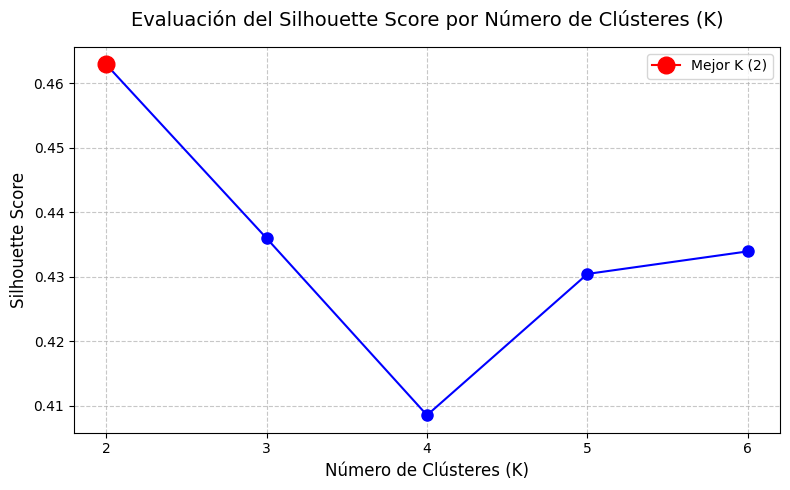

In [15]:
columnas_modelo = [
    'ratio_albumina_creatinina', 
    'proteina_c_reactiva_mg_l', 
    'trigliceridos_mmol_l', 
    'imc'
]

X = var_num[columnas_modelo].copy()

valores_k = [2, 3, 4, 5, 6]
scores_silhouette = []

print("\n--- EVALUANDO K-MEANS ---")
for k in valores_k:
    # Configuramos el modelo KMeans
    # random_state=42 asegura que los resultados sean reproducibles
    # n_init=10 es una buena práctica para evitar mínimos locales
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Entrenamos el modelo y predecimos a qué clúster pertenece cada paciente
    etiquetas_clusters = modelo_kmeans.fit_predict(X)
    
    # Calculamos el Silhouette Score
    score = silhouette_score(X, etiquetas_clusters)
    scores_silhouette.append(score)
    
    print(f"Para K = {k} -> Silhouette Score: {score:.4f}")

# 4. Encontrar el mejor K automáticamente
mejor_k = valores_k[scores_silhouette.index(max(scores_silhouette))]
print(f"\n🌟 El número óptimo de clústeres según Silhouette es: K = {mejor_k} (Score: {max(scores_silhouette):.4f})")

# 5. Visualizar los resultados en una gráfica
plt.figure(figsize=(8, 5))
plt.plot(valores_k, scores_silhouette, marker='o', linestyle='-', color='b', markersize=8)
plt.title('Evaluación del Silhouette Score por Número de Clústeres (K)', fontsize=14, pad=15)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(valores_k)
plt.grid(True, linestyle='--', alpha=0.7)

# Resaltar el punto máximo
plt.plot(mejor_k, max(scores_silhouette), marker='o', color='red', markersize=12, label=f'Mejor K ({mejor_k})')
plt.legend()

plt.tight_layout()
plt.show()


--- EVALUANDO K-MEANS ---
Para K = 2 -> Silhouette Score: 0.4313
Para K = 3 -> Silhouette Score: 0.4036
Para K = 4 -> Silhouette Score: 0.3718
Para K = 5 -> Silhouette Score: 0.3750
Para K = 6 -> Silhouette Score: 0.3652

🌟 El número óptimo de clústeres según Silhouette es: K = 2 (Score: 0.4313)


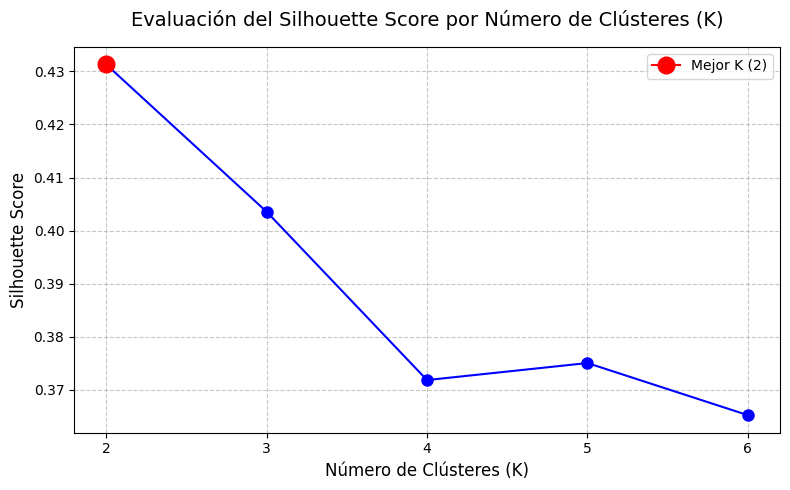

In [17]:
columnas_modelo = [
    'ratio_albumina_creatinina', 
    'plomo_sangre_umol_l', 
    'proteina_c_reactiva_mg_l', 
    'rigidez_mediana_kpa', 
    'trigliceridos_mmol_l',
    'imc'
]

X = var_num[columnas_modelo].copy()

valores_k = [2, 3, 4, 5, 6]
scores_silhouette = []

print("\n--- EVALUANDO K-MEANS ---")
for k in valores_k:
    # Configuramos el modelo KMeans
    # random_state=42 asegura que los resultados sean reproducibles
    # n_init=10 es una buena práctica para evitar mínimos locales
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Entrenamos el modelo y predecimos a qué clúster pertenece cada paciente
    etiquetas_clusters = modelo_kmeans.fit_predict(X)
    
    # Calculamos el Silhouette Score
    score = silhouette_score(X, etiquetas_clusters)
    scores_silhouette.append(score)
    
    print(f"Para K = {k} -> Silhouette Score: {score:.4f}")

# 4. Encontrar el mejor K automáticamente
mejor_k = valores_k[scores_silhouette.index(max(scores_silhouette))]
print(f"\n🌟 El número óptimo de clústeres según Silhouette es: K = {mejor_k} (Score: {max(scores_silhouette):.4f})")

# 5. Visualizar los resultados en una gráfica
plt.figure(figsize=(8, 5))
plt.plot(valores_k, scores_silhouette, marker='o', linestyle='-', color='b', markersize=8)
plt.title('Evaluación del Silhouette Score por Número de Clústeres (K)', fontsize=14, pad=15)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(valores_k)
plt.grid(True, linestyle='--', alpha=0.7)

# Resaltar el punto máximo
plt.plot(mejor_k, max(scores_silhouette), marker='o', color='red', markersize=12, label=f'Mejor K ({mejor_k})')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#comando de LIMPIEZA DE KERNEL PARA EVITAR QUE SE MEZCLEN VARIBALES DE DISTINTAS PRUEBAS
%reset -f
%reset -f in out dhist

Flushing input history
Flushing output cache (0 entries)
Flushing directory history


-----------------------------------------------------
-----------------------------------------------------

PRUEBAS EXTRA


## Transformación logaritmica para variables con mucho sesgo

Cargamos el mismo conjunto de datos previo a la estandarización y eliminamos las mismas variables que antes

In [192]:
import pandas as pd
from sklearn.cluster import KMeans
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import unicodedata
import re
import gower

import kmedoids # Nueva librería para PAM
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.spatial.distance as ssd
import prince
import numpy as np

from itertools import combinations
import heapq 

In [180]:
trainset = pd.read_csv("train_imputado.csv")

In [181]:
trainset.head(10)

,edad_an,tamano_hogar,psu,ratio_pobreza,tiempo_seg_cond1,tiempo_seg_cond2,tiempo_seg_cond3,tiempo_seg_cond4,pulso,peso_kg,...,elegibilidad_balance,convulsiones,caidas,fracturas,medicacion_osteoporosis,aprueba_cond4,tamano_manguito_pa,estado_elastografia,tipo_sonda_elasto,raza_etnia
0,46.0,5.0,2.0,4.62,15.0,15.0,30.0,30.0,66.0,111.6,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
1,57.0,3.0,2.0,2.17,15.0,15.0,30.0,30.0,73.0,124.1,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
2,48.0,3.0,2.0,5.00,15.0,15.0,30.0,30.0,67.0,89.3,...,0,0,0,1,0,1,4.0,1,b'M',3.0
3,40.0,5.0,1.0,3.11,15.0,15.0,30.0,30.0,81.0,81.9,...,1,0,0,0,0,1,3.0,1,b'M',2.0
4,66.0,3.0,2.0,3.47,15.0,15.0,30.0,8.0,103.0,77.4,...,1,0,0,0,0,0,3.0,1,b'M',6.0
5,27.0,2.0,1.0,5.00,15.0,15.0,30.0,30.0,69.0,50.8,...,1,0,0,0,0,1,3.0,1,b'M',7.0
6,69.0,1.0,1.0,2.43,15.0,15.0,30.0,30.0,50.0,86.4,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
7,33.0,5.0,2.0,1.05,15.0,15.0,30.0,30.0,58.0,84.2,...,1,0,0,0,0,1,3.0,1,b'M',3.0
8,54.0,4.0,1.0,5.00,15.0,15.0,30.0,22.0,73.0,94.2,...,1,0,0,0,0,1,4.0,1,b'XL',3.0
9,40.0,1.0,1.0,5.00,15.0,15.0,30.0,2.0,51.0,66.5,...,1,0,0,0,0,0,3.0,1,b'M',3.0


In [182]:
# 1. Cargar diccionario



ruta_diccionario = "../data/Diccionario_TFM_CompletoMF.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
var_categoricas = [col for col in cols_categoricas if col in trainset.columns]

cols_numericas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("num", na=False), "Qué es"
].tolist()
var_numericas = [col for col in cols_numericas if col in trainset.columns]

trainset[var_numericas] = trainset[var_numericas].astype('float64')
trainset[var_categoricas] = trainset[var_categoricas].astype('object')

print(f"Número de columnas categóricas: {len(var_categoricas)}")
print(var_categoricas)

print(f"Número de columnas numéricas: {len(var_numericas)}")
print(var_numericas)

Número de columnas categóricas: 16
['genero', 'periodo_examen', 'pais_nacimiento', 'toma_suplementos', 'toma_antiacidos', 'estado_examen_balance', 'elegibilidad_balance', 'convulsiones', 'caidas', 'fracturas', 'medicacion_osteoporosis', 'aprueba_cond4', 'tamano_manguito_pa', 'estado_elastografia', 'tipo_sonda_elasto', 'raza_etnia']
Número de columnas numéricas: 46
['edad_an', 'tamano_hogar', 'psu', 'ratio_pobreza', 'tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'tiempo_seg_cond4', 'pulso', 'peso_kg', 'altura_cm', 'imc', 'largo_pierna_superior_cm', 'largo_brazo_superior_cm', 'medidas_validas_elasto', 'intentos_totales_elasto', 'rigidez_mediana_kpa', 'rigidez_iqr', 'ratio_iqr_mediana', 'cap_mediana_db_m', 'cap_iqr', 'albumina_orina_mg_l', 'creatinina_orina_umol_l', 'ratio_albumina_creatinina', 'peso_flebotomia', 'proteina_c_reactiva_mg_l', 'leucocitos_totales', 'linfocitos_abs', 'monocitos_abs', 'neutrofilos_abs', 'eosinofilos_abs', 'eritrocitos_totales', 'hemoglobina_g_dl',

eliminamos las mismas variables que en el apartado anterior

In [184]:
columnas_a_eliminar = ['tiempo_seg_cond1', 'tiempo_seg_cond2', 'tiempo_seg_cond3', 'peso_kg', 'albumina_orina_mg_l', 'neutrofilos_abs','rigidez_iqr', 'ratio_iqr_mediana','medidas_validas_elasto','intentos_totales_elasto']

# Utilizamos el método .drop() especificando que queremos eliminar columnas
trainset = trainset.drop(columns=columnas_a_eliminar)
trainset.shape

(1919, 52)

In [185]:
var_num = trainset.select_dtypes(include=['number'])
var_num.shape

(1919, 36)

obtenemos el skew para cada variable: medida estadística que describe la falta de simetría en la distribución de tus datos alrededor de su media.

In [186]:
asimetria = var_num.skew().sort_values(ascending=False)

print("--- Nivel de Asimetría (Skewness) de las Variables ---")
print("Valores ideales: entre -1 y 1. Valores > 1 o < -1 indican asimetría severa.\n")
print(asimetria)

--- Nivel de Asimetría (Skewness) de las Variables ---
Valores ideales: entre -1 y 1. Valores > 1 o < -1 indican asimetría severa.

plomo_sangre_umol_l               19.482658
ratio_albumina_creatinina         14.215589
rigidez_mediana_kpa                7.974745
proteina_c_reactiva_mg_l           6.952438
trigliceridos_mmol_l               6.916607
cadmio_sangre_nmol_l               5.434901
eosinofilos_abs                    5.417549
selenio_sangre_umol_l              5.352683
ancho_distribucion_eritrocitos     5.211623
mercurio_sangre_nmol_l             4.743745
cap_iqr                            1.838814
peso_flebotomia                    1.829170
manganeso_sangre_nmol_l            1.501256
creatinina_orina_umol_l            1.216544
monocitos_abs                      1.209084
linfocitos_abs                     1.156344
imc                                1.138741
leucocitos_totales                 1.137664
hdl_mmol_l                         1.131395
tamano_hogar                    

In [188]:
skew_actual = var_num.skew()
var_num_log = var_num.copy()

# 2. Filtrar las variables con asimetría severa
variables_sesgadas = skew_actual[skew_actual.abs() > 1.6].index.tolist()

print("--- VARIABLES DETECTADAS PARA TRANSFORMACIÓN ---")
for col in variables_sesgadas:
    print(f"- {col} (Skew original: {skew_actual[col]:.2f})")

# 3. Aplicar la transformación logarítmica
# Usamos np.log1p(x) que es el equivalente a log(x + 1), ideal para evitar errores si hay valores de 0
for col in variables_sesgadas:
    # Verificamos que no haya valores negativos antes de aplicar el logaritmo
    if (var_num_log[col] < 0).any():
        print(f"⚠️ Advertencia: {col} tiene valores negativos. No se aplicó logaritmo.")
    else:
        var_num_log[col] = np.log1p(var_num_log[col])

print("\nTransformación logarítmica aplicada con éxito.")

# 4. Verificar los nuevos niveles de asimetría para confirmar la mejora
print("\n--- NUEVA ASIMETRÍA TRAS LA TRANSFORMACIÓN ---")
skew_nuevo = var_num_log[variables_sesgadas].skew()
for col in variables_sesgadas:
    print(f"- {col} (Nuevo Skew: {skew_nuevo[col]:.2f})")

--- VARIABLES DETECTADAS PARA TRANSFORMACIÓN ---
- rigidez_mediana_kpa (Skew original: 7.97)
- cap_iqr (Skew original: 1.84)
- ratio_albumina_creatinina (Skew original: 14.22)
- peso_flebotomia (Skew original: 1.83)
- proteina_c_reactiva_mg_l (Skew original: 6.95)
- eosinofilos_abs (Skew original: 5.42)
- ancho_distribucion_eritrocitos (Skew original: 5.21)
- trigliceridos_mmol_l (Skew original: 6.92)
- plomo_sangre_umol_l (Skew original: 19.48)
- cadmio_sangre_nmol_l (Skew original: 5.43)
- mercurio_sangre_nmol_l (Skew original: 4.74)
- selenio_sangre_umol_l (Skew original: 5.35)

Transformación logarítmica aplicada con éxito.

--- NUEVA ASIMETRÍA TRAS LA TRANSFORMACIÓN ---
- rigidez_mediana_kpa (Nuevo Skew: 2.00)
- cap_iqr (Nuevo Skew: -0.26)
- ratio_albumina_creatinina (Nuevo Skew: 1.66)
- peso_flebotomia (Nuevo Skew: 0.10)
- proteina_c_reactiva_mg_l (Nuevo Skew: 1.02)
- eosinofilos_abs (Nuevo Skew: 2.57)
- ancho_distribucion_eritrocitos (Nuevo Skew: 2.85)
- trigliceridos_mmol_l (Nu

se puede observar que para ciertas variables la transformación logaritmica no ha sido del todo útil esto es debido a:

1. medidas como plomo_sangre_umol_l son muy pequeñas y la la función log1p(x) uma 1 antes de sacar el logaritmo por tanto si se le suma 1 a un valor muy pequeño es practicamnete 1.

Para estos valores se aplica la transformación de raiz cuadrada.

In [189]:
skew_actual = var_num.skew()
var_num_log = var_num.copy()

# 2. Filtrar las variables con asimetría severa
variables_sesgadas = skew_actual[skew_actual.abs() > 1.6].index.tolist()

print("--- VARIABLES DETECTADAS PARA TRANSFORMACIÓN ---")
for col in variables_sesgadas:
    print(f"- {col} (Skew original: {skew_actual[col]:.2f})")

# Definimos las variables rebeldes que necesitan raíz cuadrada en lugar de logaritmo
variables_raiz = ['plomo_sangre_umol_l']

print("\n--- APLICANDO TRANSFORMACIONES ---")
# 3. Aplicar la transformación (Logaritmo o Raíz Cuadrada)
for col in variables_sesgadas:
    # Si la variable está en nuestra lista de excepciones, aplicamos raíz cuadrada
    if col in variables_raiz:
        var_num_log[col] = np.sqrt(var_num_log[col])
        print(f"✓ Raíz cuadrada aplicada a: {col}")
    else:
        # Para el resto, verificamos que no haya valores negativos antes de aplicar el logaritmo
        if (var_num_log[col] < 0).any():
            print(f"⚠️ Advertencia: {col} tiene valores negativos. No se aplicó logaritmo.")
        else:
            var_num_log[col] = np.log1p(var_num_log[col])
            # print(f"✓ Logaritmo aplicado a: {col}") # Opcional: descomentar para ver el progreso

print("\nTransformaciones aplicadas con éxito.")

# 4. Verificar los nuevos niveles de asimetría para confirmar la mejora
print("\n--- NUEVA ASIMETRÍA TRAS LAS TRANSFORMACIONES ---")
skew_nuevo = var_num_log[variables_sesgadas].skew()
for col in variables_sesgadas:
    print(f"- {col} (Nuevo Skew: {skew_nuevo[col]:.2f})")

--- VARIABLES DETECTADAS PARA TRANSFORMACIÓN ---
- rigidez_mediana_kpa (Skew original: 7.97)
- cap_iqr (Skew original: 1.84)
- ratio_albumina_creatinina (Skew original: 14.22)
- peso_flebotomia (Skew original: 1.83)
- proteina_c_reactiva_mg_l (Skew original: 6.95)
- eosinofilos_abs (Skew original: 5.42)
- ancho_distribucion_eritrocitos (Skew original: 5.21)
- trigliceridos_mmol_l (Skew original: 6.92)
- plomo_sangre_umol_l (Skew original: 19.48)
- cadmio_sangre_nmol_l (Skew original: 5.43)
- mercurio_sangre_nmol_l (Skew original: 4.74)
- selenio_sangre_umol_l (Skew original: 5.35)

--- APLICANDO TRANSFORMACIONES ---
✓ Raíz cuadrada aplicada a: plomo_sangre_umol_l

Transformaciones aplicadas con éxito.

--- NUEVA ASIMETRÍA TRAS LAS TRANSFORMACIONES ---
- rigidez_mediana_kpa (Nuevo Skew: 2.00)
- cap_iqr (Nuevo Skew: -0.26)
- ratio_albumina_creatinina (Nuevo Skew: 1.66)
- peso_flebotomia (Nuevo Skew: 0.10)
- proteina_c_reactiva_mg_l (Nuevo Skew: 1.02)
- eosinofilos_abs (Nuevo Skew: 2.57)


In [193]:
print("=" * 80)
print("FORWARD SELECTION")
print("=" * 80)

rango_k = range(2, 6) # K=2, 3, 4, 5
max_variables = 20    # Límite máximo de variables a agrupar
columnas_totales = var_num_log.columns.tolist()

resultados_finales = {}
campeon_global_score = -1
campeon_global_k = -1
campeon_global_vars = []

for k in rango_k:
    print(f"\n[ Iniciando búsqueda para K={k} ]")
    
    columnas_disponibles = columnas_totales.copy()
    variables_seleccionadas = []
    
    # --- PASO 1: Buscar el mejor PAR inicial (La base sólida) ---
    mejor_score_par = -1
    mejor_par = ()
    
    # Probamos las 1035 parejas posibles
    for combo in combinations(columnas_disponibles, 2):
        X_subset = var_num_log[list(combo)]
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        labels = kmeans.fit_predict(X_subset)
        score = silhouette_score(X_subset, labels)
        
        if score > mejor_score_par:
            mejor_score_par = score
            mejor_par = combo
            
    # Fijamos el mejor par y lo sacamos de las disponibles
    variables_seleccionadas.extend(mejor_par)
    for var in mejor_par:
        columnas_disponibles.remove(var)
        
    print(f"  -> Mejor par inicial: {mejor_par} (Score: {mejor_score_par:.4f})")
    
    # Guardamos el historial para ver en qué momento el score hace "pico"
    historial_scores = [mejor_score_par]
    
    # --- PASO 2: Forward Selection (Añadir 1 a 1 hasta max_variables) ---
    for paso in range(3, max_variables + 1):
        mejor_score_paso = -1
        mejor_variable_paso = None
        
        # Probamos a añadir cada una de las variables que quedan libres
        for var_candidata in columnas_disponibles:
            features_a_probar = variables_seleccionadas + [var_candidata]
            X_subset = var_num_log[features_a_probar]
            
            kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
            labels = kmeans.fit_predict(X_subset)
            score = silhouette_score(X_subset, labels)
            
            if score > mejor_score_paso:
                mejor_score_paso = score
                mejor_variable_paso = var_candidata
                
        # Consolidamos la variable ganadora de este paso
        variables_seleccionadas.append(mejor_variable_paso)
        columnas_disponibles.remove(mejor_variable_paso)
        historial_scores.append(mejor_score_paso)
        
        print(f"  -> + Variable {paso}: '{mejor_variable_paso}' | Nuevo Score: {mejor_score_paso:.4f}")

    # --- PASO 3: Encontrar el pico máximo para este K ---
    # Es posible que el score baje al añadir la 5ª variable. 
    # Nos quedamos con el mejor momento de la historia.
    indice_mejor_momento = historial_scores.index(max(historial_scores))
    score_pico = historial_scores[indice_mejor_momento]
    
    # El índice 0 equivale a 2 variables, índice 1 a 3 variables, etc.
    vars_en_pico = variables_seleccionadas[:indice_mejor_momento + 2]
    
    resultados_finales[k] = {
        'score': score_pico,
        'variables': vars_en_pico
    }
    
    # Actualizar campeón global absoluto
    if score_pico > campeon_global_score:
        campeon_global_score = score_pico
        campeon_global_k = k
        campeon_global_vars = vars_en_pico

print("\n" + "=" * 80)
print("🏆 RESULTADOS FINALES: FORWARD SELECTION 🏆")
print("=" * 80)

print(f"\n🌟 EL CAMPEÓN ABSOLUTO:")
print(f"  -> K Óptimo: {campeon_global_k}")
print(f"  -> Silhouette Score Máximo: {campeon_global_score:.4f}")
print(f"  -> Variables óptimas ({len(campeon_global_vars)}): {', '.join(campeon_global_vars)}")

print("\n--- MEJOR COMBINACIÓN ENCONTRADA PARA CADA K ---")
for k in rango_k:
    res = resultados_finales[k]
    print(f"\nPara K={k}:")
    print(f"  -> Silhouette Score: {res['score']:.4f}")
    print(f"  -> N Variables: {len(res['variables'])}")
    print(f"  -> Variables: {', '.join(res['variables'])}")

FORWARD SELECTION

[ Iniciando búsqueda para K=2 ]
  -> Mejor par inicial: ('psu', 'plomo_sangre_umol_l') (Score: 0.9246)
  -> + Variable 3: 'ancho_distribucion_eritrocitos' | Nuevo Score: 0.8794
  -> + Variable 4: 'selenio_sangre_umol_l' | Nuevo Score: 0.8293
  -> + Variable 5: 'eosinofilos_abs' | Nuevo Score: 0.7880
  -> + Variable 6: 'tiempo_seg_cond4' | Nuevo Score: 0.7697
  -> + Variable 7: 'monocitos_abs' | Nuevo Score: 0.7684
  -> + Variable 8: 'trigliceridos_mmol_l' | Nuevo Score: 0.7653
  -> + Variable 9: 'rigidez_mediana_kpa' | Nuevo Score: 0.7620
  -> + Variable 10: 'hdl_mmol_l' | Nuevo Score: 0.7586
  -> + Variable 11: 'eritrocitos_totales' | Nuevo Score: 0.7539
  -> + Variable 12: 'cap_iqr' | Nuevo Score: 0.7488
  -> + Variable 13: 'cadmio_sangre_nmol_l' | Nuevo Score: 0.7430
  -> + Variable 14: 'linfocitos_abs' | Nuevo Score: 0.7372
  -> + Variable 15: 'peso_flebotomia' | Nuevo Score: 0.7308
  -> + Variable 16: 'proteina_c_reactiva_mg_l' | Nuevo Score: 0.7236
  -> + Varia

------------------------------------------------------------------------------


Aunque la variable está estandarizada y la varianza es la misma siempre si se puede observar que para las 3 primeras pruebas un 85% de pacientes obtienen el máximo valor registrado por lo que casi todos la superan de la misma forma. Sin embargo en el ultimo caso esto se reduce al 50 %.

Por eso se va a conservar la variable tiempo_seg_cond4 haciendo un ajuste por edad utilizando un modelo de regresión lineal donde la Edad predice el Tiempo en la Condición 4. Luego, se calculan los residuos (la diferencia entre lo que la persona aguantó y lo que se esperaba que aguantara para su edad). Si usas esos residuos en el clustering, el algoritmo agrupará a personas que tienen un equilibrio peor de lo normal para su edad.

De esta forma evitamos que la relación principal de esta varibale c

In [ ]:
# from sklearn.linear_model import LinearRegression

# print("--- AJUSTE DE LA CONDICIÓN 4 POR EDAD ---\n")

# # Verificamos que tengamos las columnas necesarias
# if 'edad_an' in df.columns and 'tiempo_seg_cond4' in df.columns:
    
#     # Preparamos las variables (X = Edad, y = Tiempo en Condición 4)
#     # Hacemos un reshape porque sklearn requiere un array 2D para X
#     X_edad = df['edad_an'].values.reshape(-1, 1)
#     y_cond4 = df['tiempo_seg_cond4'].values
    
#     # Entrenamos el modelo de regresión
#     modelo = LinearRegression()
#     modelo.fit(X_edad, y_cond4)
    
#     # Calculamos el tiempo "esperado" para la edad de cada paciente
#     tiempo_esperado = modelo.predict(X_edad)
    
#     # CALCULAMOS EL RESIDUO: Tiempo Real - Tiempo Esperado
#     # Un valor negativo significa "rindió peor de lo esperado para su edad"
#     df['residuo_cond4_ajustado_edad'] = y_cond4 - tiempo_esperado
    
#     print("Regresión completada.")
#     print(f"Coeficiente de la edad: {modelo.coef_[0]:.4f} (segundos que se pierden por año de edad)")
    
#     # Mostramos un resumen de la nueva variable
#     print("\nResumen estadístico del Residuo Ajustado:")
#     print(df['residuo_cond4_ajustado_edad'].describe())
    
#     # ----------------------------------------------------------------
#     # PASO FINAL PARA EL CLUSTERING:
#     # Elimina las columnas de tiempo crudas y quédate solo con el residuo.
#     # ----------------------------------------------------------------